In [ ]:
# ============================================================
# BIRDS CubeSat - ML Based Autonomous Power Management
# Notebook 17: Decision Tree Classifier
# Dataset : TSURU On-Orbit EPS Data (Jara et al., 2022)
# DOI     : 10.1016/j.dib.2022.108697
# ------------------------------------------------------------
# Algorithm : DecisionTreeClassifier
# Training  : Recursive binary splitting via impurity reduction
# Criterion : Gini impurity or Entropy (information gain)
# Tuning    : max_depth, min_samples_split,
#             min_samples_leaf, criterion
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree          import (DecisionTreeClassifier,
                                   plot_tree, export_text)
from sklearn.preprocessing  import StandardScaler
from sklearn.model_selection import (TimeSeriesSplit, RandomizedSearchCV,
                                     cross_val_score, learning_curve)
from sklearn.metrics         import (accuracy_score, f1_score,
                                     precision_score, recall_score,
                                     confusion_matrix, classification_report,
                                     ConfusionMatrixDisplay)
from sklearn.inspection      import permutation_importance
from scipy.stats             import randint

SEED = 42
np.random.seed(SEED)

print("All libraries imported successfully")
print()
print("Decision Tree Classifier")
print("Training  : Recursive binary splitting — no gradient descent")
print("            At each node: find feature + threshold that")
print("            minimises weighted child impurity (Gini/Entropy)")
print("Splitting : Gini = 1 - Σpᵢ²")
print("            Entropy = -Σpᵢ log₂(pᵢ)")
print("            Best split = max impurity reduction (information gain)")
print()
print("Why RandomizedSearchCV:")
print("  max_depth (1–50), min_samples_split (2–200),")
print("  min_samples_leaf (1–100) are all integers with large ranges.")
print("  Combined with 2 criteria = thousands of combinations.")
print("  RandomizedSearch with randint distributions samples")
print("  this space efficiently — far faster than exhaustive grid")
print("  while finding near-optimal params. (Bergstra & Bengio, 2012)")
print()
print("Classification Tasks:")
print("  Task 1 : Power State   — CHARGING / DISCHARGING / CRITICAL")
print("  Task 2 : Eclipse State — SUNLIGHT / ECLIPSE")
print("  Task 3 : Power Level   — HIGH / MEDIUM / LOW")

All libraries imported successfully

Decision Tree Classifier
Training  : Recursive binary splitting — no gradient descent
            At each node: find feature + threshold that
            minimises weighted child impurity (Gini/Entropy)
Splitting : Gini = 1 - Σpᵢ²
            Entropy = -Σpᵢ log₂(pᵢ)
            Best split = max impurity reduction (information gain)

Why RandomizedSearchCV:
  max_depth (1–50), min_samples_split (2–200),
  min_samples_leaf (1–100) are all integers with large ranges.
  Combined with 2 criteria = thousands of combinations.
  RandomizedSearch with randint distributions samples
  this space efficiently — far faster than exhaustive grid
  while finding near-optimal params. (Bergstra & Bengio, 2012)

Classification Tasks:
  Task 1 : Power State   — CHARGING / DISCHARGING / CRITICAL
  Task 2 : Eclipse State — SUNLIGHT / ECLIPSE
  Task 3 : Power Level   — HIGH / MEDIUM / LOW


In [ ]:
# ============================================================
# SECTION 2: DATA LOADING + CLASS DEFINITION
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/TSURU_cleaned.csv')
print("Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")

# sin_orbit and cos_orbit already exist in dataset

# ── TASK 1: Power State — 3 classes ────────────────────────
def define_power_state(row):
    if   row['Vbat (V)'] < 3.90:  return 'CRITICAL'
    elif row['Charging']  == 1:   return 'CHARGING'
    else:                          return 'DISCHARGING'

df['Power_State']   = df.apply(define_power_state, axis=1)
df['Eclipse_State'] = df['Eclipse'].map({0: 'SUNLIGHT', 1: 'ECLIPSE'})
# Power_Level already exists in dataset

# ── Feature sets — leakage-free ─────────────────────────────
PANEL_V  = ['Vpy (mV)', 'Vpx (mV)', 'Vmz (mV)',
            'Vmx (mV)', 'Vpz (mV)', 'V_panel_avg (mV)']
PANEL_T  = ['Tpy (°C)', 'Tpx (°C)', 'Tmz (°C)',
            'Tmx (°C)', 'Tpz (°C)', 'T_panel_avg (°C)']
ORBIT_FT = ['sin_orbit', 'cos_orbit']
SHARED   = PANEL_V + PANEL_T + ['Tbatt (℃)'] + ORBIT_FT

TASK1_FEATS = [f for f in SHARED
               if f not in ['Charging','Ibatt(mA)','P_batt (µW)','Vbat (V)']]
TASK2_FEATS = [f for f in SHARED + ['Vbat (V)']
               if f not in ['Eclipse','P_solar_total (µW)',
                             'Ipy (mA)','Ipx (mA)','Imz (mA)',
                             'Imx (mA)','Ipz (mA)']]
TASK3_FEATS = [f for f in SHARED
               if f not in ['Vbat (V)','P_solar_total (µW)',
                             'Charging','Ibatt(mA)','P_batt (µW)']]

# ── TimeSeriesSplit — last fold for train/test ──────────────
tscv      = TimeSeriesSplit(n_splits=5)
splits    = list(tscv.split(df))
train_idx = splits[-1][0]
test_idx  = splits[-1][1]

# ── NOTE: Decision Trees do NOT require StandardScaler ──────
# Trees split on thresholds — feature scale is irrelevant.
# Raw values used directly. This is a key difference from
# SVM and KNN which are distance/margin-based algorithms.
datasets = {}
for task, feats, target in [
    ('Power_State',   TASK1_FEATS, 'Power_State'),
    ('Eclipse_State', TASK2_FEATS, 'Eclipse_State'),
    ('Power_Level',   TASK3_FEATS, 'Power_Level'),
]:
    Xtr = df[feats].iloc[train_idx].values
    Xte = df[feats].iloc[test_idx].values
    ytr = df[target].iloc[train_idx]
    yte = df[target].iloc[test_idx]
    datasets[task] = dict(
        X_train=Xtr, X_test=Xte,
        y_train=ytr, y_test=yte,
        features=feats,
        X_full=df[feats].values,
        y_full=df[target]
    )

print(f"\nTrain size : {len(train_idx)}")
print(f"Test size  : {len(test_idx)}")
print()
print("NOTE: No StandardScaler — Decision Trees split on thresholds,")
print("      feature scale does not affect split quality or impurity.")
print()
print("=" * 50)
print("CLASS DISTRIBUTIONS")
print("=" * 50)
for task, d in datasets.items():
    print(f"\n{task}:")
    for cls, cnt in d['y_full'].value_counts().items():
        print(f"  {cls:<15}: {cnt:>6} ({cnt/len(df)*100:.1f}%)")

print("\nFeature counts:")
for task, d in datasets.items():
    print(f"  {task}: {len(d['features'])} features")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully!
Shape: 23259 rows x 35 columns

Train size : 19383
Test size  : 3876

NOTE: No StandardScaler — Decision Trees split on thresholds,
      feature scale does not affect split quality or impurity.

CLASS DISTRIBUTIONS

Power_State:
  CHARGING       :  13523 (58.1%)
  DISCHARGING    :   9571 (41.1%)
  CRITICAL       :    165 (0.7%)

Eclipse_State:
  SUNLIGHT       :  15537 (66.8%)
  ECLIPSE        :   7722 (33.2%)

Power_Level:
  Low            :   7753 (33.3%)
  Medium         :   7753 (33.3%)
  High           :   7753 (33.3%)

Feature counts:
  Power_State: 15 features
  Eclipse_State: 16 features
  Power_Level: 15 features


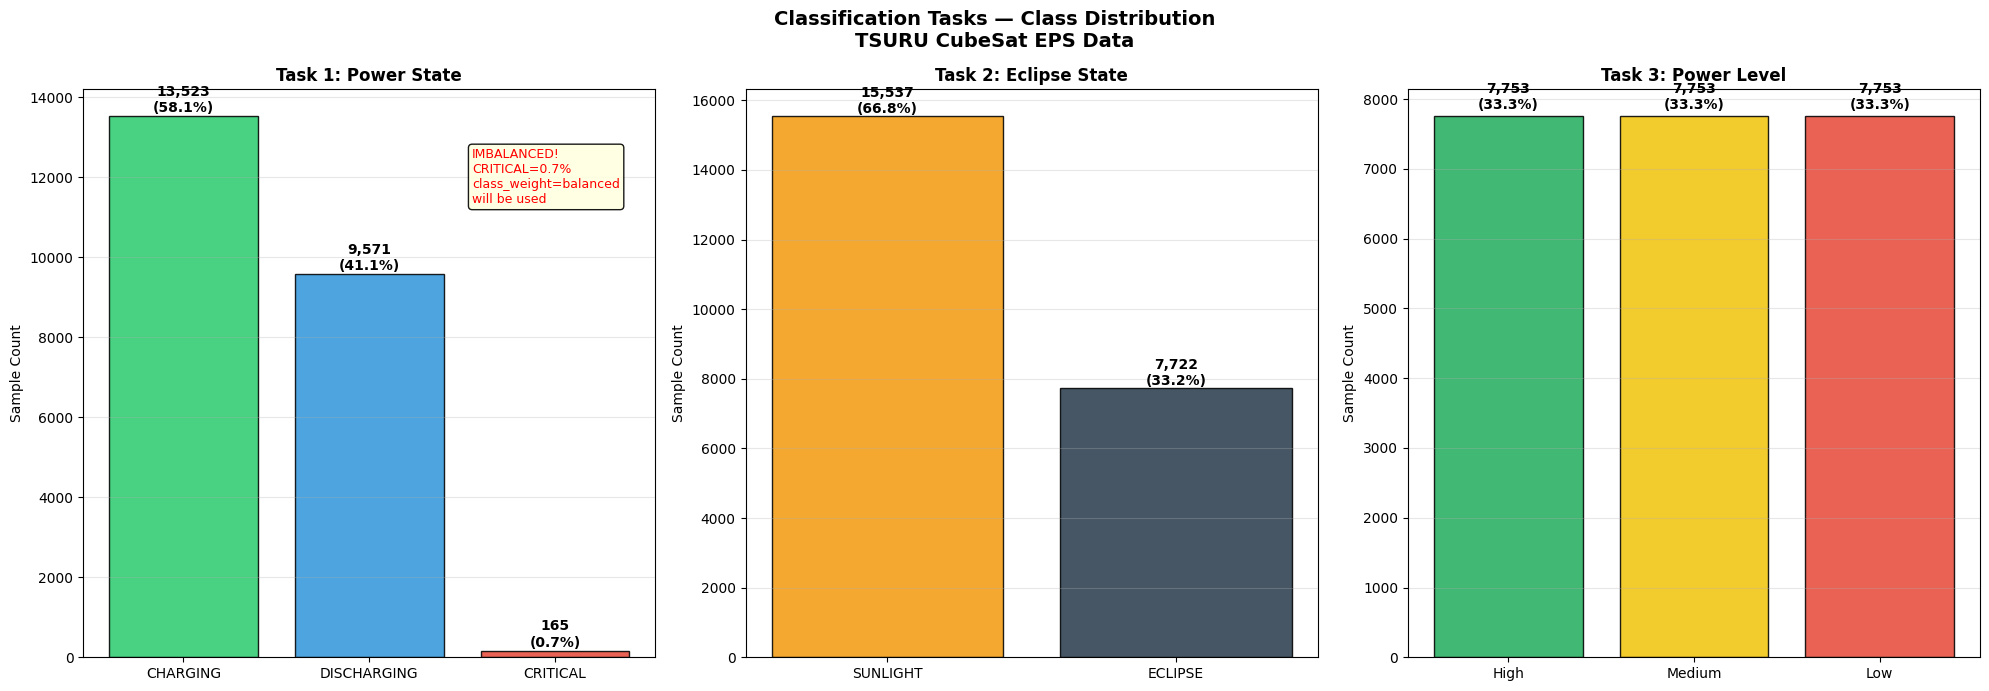

Class distribution plot saved.


In [ ]:
# ============================================================
# SECTION 3: CLASS DISTRIBUTION EDA
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Classification Tasks — Class Distribution\nTSURU CubeSat EPS Data', fontsize=14, fontweight='bold')

# Task 1 — Power State
vc1   = df['Power_State'].value_counts()
cls1  = ['CHARGING', 'DISCHARGING', 'CRITICAL']
vals1 = [vc1.get(c, 0) for c in cls1]
bars1 = axes[0].bar(cls1, vals1, color=['#2ecc71','#3498db','#e74c3c'], edgecolor='black', alpha=0.88)
axes[0].set_title('Task 1: Power State', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Sample Count')
axes[0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars1, vals1):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+100, f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10, fontweight='bold')
axes[0].text(0.68, 0.80, 'IMBALANCED!\nCRITICAL=0.7%\nclass_weight=balanced\nwill be used', transform=axes[0].transAxes, fontsize=9, color='red', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

# Task 2 — Eclipse State
vc2   = df['Eclipse_State'].value_counts()
cls2  = ['SUNLIGHT', 'ECLIPSE']
vals2 = [vc2.get(c, 0) for c in cls2]
bars2 = axes[1].bar(cls2, vals2, color=['#f39c12','#2c3e50'], edgecolor='black', alpha=0.88)
axes[1].set_title('Task 2: Eclipse State', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Sample Count')
axes[1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars2, vals2):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+100, f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10, fontweight='bold')

# Task 3 — Power Level (High/Medium/Low — matches dataset exactly)
vc3   = df['Power_Level'].value_counts()
cls3  = ['High', 'Medium', 'Low']
vals3 = [vc3.get(c, 0) for c in cls3]
bars3 = axes[2].bar(cls3, vals3, color=['#27ae60','#f1c40f','#e74c3c'], edgecolor='black', alpha=0.88)
axes[2].set_title('Task 3: Power Level', fontweight='bold', fontsize=12)
axes[2].set_ylabel('Sample Count')
axes[2].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars3, vals3):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+100, f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('00_class_distribution.png', dpi=72, bbox_inches='tight')
plt.show()
print("Class distribution plot saved.")

## Section 3: Class Distribution Analysis

**Power State (Task 1):** Severely imbalanced — CHARGING 58.1% (13,523),
DISCHARGING 41.1% (9,571), CRITICAL only 0.7% (165 samples).
class_weight='balanced' is mandatory. Without it, the tree never splits
toward CRITICAL — 165 samples contribute negligible impurity reduction
compared to 13,523 CHARGING samples.

**Eclipse State (Task 2):** Moderately imbalanced — SUNLIGHT 66.8%,
ECLIPSE 33.2%. Manageable with class_weight='balanced'.

**Power Level (Task 3):** Perfectly balanced — 33.3% each class (7,753
samples). No imbalance correction needed, but class_weight='balanced'
kept for consistency.

In [ ]:
# ============================================================
# SECTION 4: BASE DECISION TREE — DEFAULT PARAMETERS
# ------------------------------------------------------------
# max_depth=None  : tree grows until all leaves are pure
#                   or contain < min_samples_split samples
# criterion=gini  : Gini = 1 - Σpᵢ²
#                   Fast to compute, numerically stable
# splitter=best   : evaluates ALL features at each node,
#                   picks the best split globally
# class_weight=balanced: wᵢ = n/(n_classes × nᵢ)
#                   automatically handles CRITICAL imbalance
# min_samples_split=2: split any node with ≥ 2 samples
# min_samples_leaf=1 : allow leaves with 1 sample
# → Unconstrained tree will overfit perfectly (train acc=1.0)
#   This is the expected baseline — pruning required.
# ============================================================

import time

results_before = {}

print("=" * 65)
print("BASE DECISION TREE — DEFAULT (unconstrained)")
print("criterion=gini | max_depth=None | class_weight=balanced")
print("=" * 65)
print()
print("Splitting algorithm:")
print("  For each node, evaluate all features and all thresholds.")
print("  Choose the (feature, threshold) pair that maximises:")
print("  ΔImpurity = Impurity(parent) - Σ(nᵢ/n)×Impurity(childᵢ)")
print("  Gini(node) = 1 - Σᵢ pᵢ²  where pᵢ = class fraction")
print("  Repeat recursively until stopping criteria met.")
print("=" * 65)

for task, d in datasets.items():
    t0 = time.time()
    model = DecisionTreeClassifier(
        criterion    = 'gini',
        splitter     = 'best',
        max_depth    = None,
        class_weight = 'balanced',
        random_state = SEED
    )
    model.fit(d['X_train'], d['y_train'])
    elapsed = time.time() - t0

    yp_train = model.predict(d['X_train'])
    yp_test  = model.predict(d['X_test'])

    train_acc = accuracy_score(d['y_train'], yp_train)
    acc       = accuracy_score(d['y_test'],  yp_test)
    f1w       = f1_score(d['y_test'], yp_test, average='weighted', zero_division=0)
    f1m       = f1_score(d['y_test'], yp_test, average='macro',    zero_division=0)
    cv_sc     = cross_val_score(
                    DecisionTreeClassifier(criterion='gini',
                                           class_weight='balanced',
                                           random_state=SEED),
                    d['X_train'], d['y_train'],
                    cv=tscv, scoring='f1_weighted', n_jobs=-1)

    results_before[task] = dict(
        model=model, y_pred=yp_test,
        train_acc=train_acc, acc=acc,
        f1w=f1w, f1m=f1m,
        cv_mean=cv_sc.mean(), cv_std=cv_sc.std(),
        depth=model.get_depth(),
        n_leaves=model.get_n_leaves())

    print(f"\nTask          : {task}")
    print(f"Classes       : {list(model.classes_)}")
    print(f"Tree depth    : {model.get_depth()}  ← unconstrained, fully grown")
    print(f"Num leaves    : {model.get_n_leaves()}")
    print(f"Train time    : {elapsed:.3f}s")
    print(f"Train Accuracy: {train_acc:.4f}  ← expected ~1.0 (overfitting)")
    print(f"Test  Accuracy: {acc:.4f}")
    print(f"F1 Weighted   : {f1w:.4f}")
    print(f"F1 Macro      : {f1m:.4f}  ← equal weight per class")
    print(f"CV F1 mean±std: {cv_sc.mean():.4f} ± {cv_sc.std():.4f}")
    print(f"\nClassification Report:")
    print(classification_report(d['y_test'], yp_test, zero_division=0))

BASE DECISION TREE — DEFAULT (unconstrained)
criterion=gini | max_depth=None | class_weight=balanced

Splitting algorithm:
  For each node, evaluate all features and all thresholds.
  Choose the (feature, threshold) pair that maximises:
  ΔImpurity = Impurity(parent) - Σ(nᵢ/n)×Impurity(childᵢ)
  Gini(node) = 1 - Σᵢ pᵢ²  where pᵢ = class fraction
  Repeat recursively until stopping criteria met.

Task          : Power_State
Classes       : ['CHARGING', 'CRITICAL', 'DISCHARGING']
Tree depth    : 34  ← unconstrained, fully grown
Num leaves    : 495
Train time    : 0.541s
Train Accuracy: 1.0000  ← expected ~1.0 (overfitting)
Test  Accuracy: 0.9058
F1 Weighted   : 0.9027
F1 Macro      : 0.6339  ← equal weight per class
CV F1 mean±std: 0.9397 ± 0.0249

Classification Report:
              precision    recall  f1-score   support

    CHARGING       0.90      0.94      0.92      1957
    CRITICAL       0.18      0.05      0.08        39
 DISCHARGING       0.92      0.89      0.90      1880

  

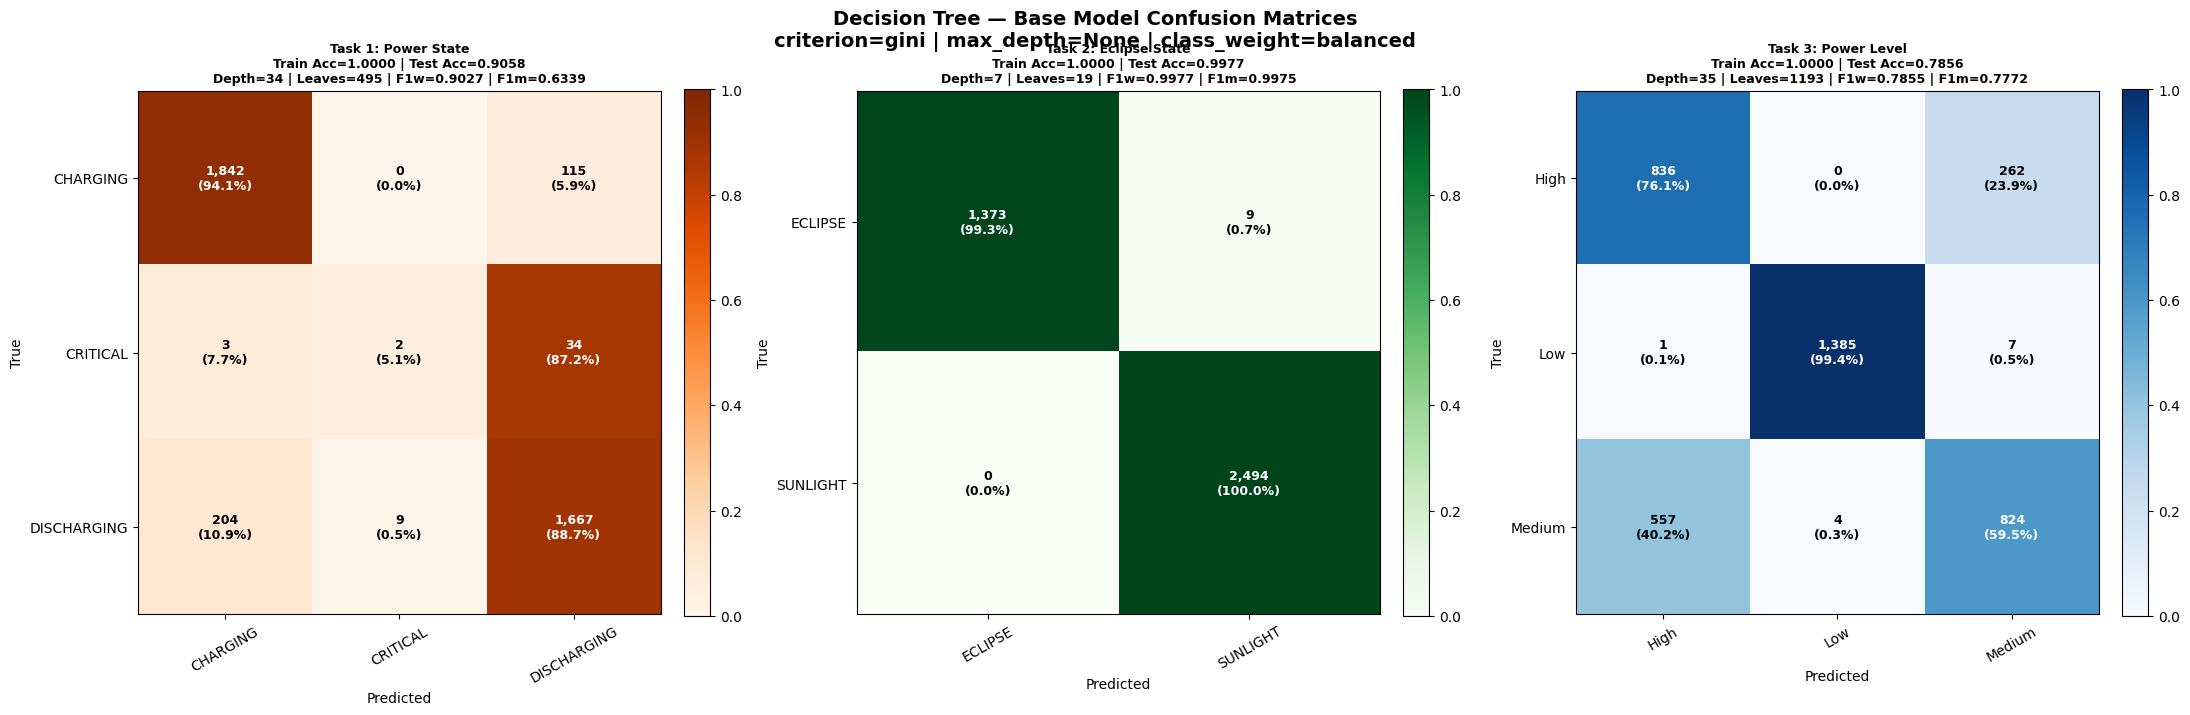

Base model confusion matrices saved.


In [ ]:
# ============================================================
# SECTION 5: BASE MODEL CONFUSION MATRICES
# Normalised row-wise — each cell = recall for that class.
# Expected: train acc ~1.0, test acc lower = classic overfit.
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Decision Tree — Base Model Confusion Matrices\n'
             'criterion=gini | max_depth=None | class_weight=balanced',
             fontsize=14, fontweight='bold')

cmaps  = ['Oranges', 'Greens', 'Blues']
titles = ['Task 1: Power State',
          'Task 2: Eclipse State',
          'Task 3: Power Level']

for ax, (task, d), cmap, title in zip(
        axes, datasets.items(), cmaps, titles):
    r       = results_before[task]
    classes = r['model'].classes_
    cm      = confusion_matrix(d['y_test'], r['y_pred'], labels=classes)
    cm_n    = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    im = ax.imshow(cm_n, cmap=cmap, vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(len(classes)))
    ax.set_xticklabels(classes, rotation=30)
    ax.set_yticks(range(len(classes)))
    ax.set_yticklabels(classes)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

    for i in range(len(classes)):
        for j in range(len(classes)):
            ax.text(j, i, f'{cm[i,j]:,}\n({cm_n[i,j]:.1%})',
                    ha='center', va='center',
                    fontsize=9, fontweight='bold',
                    color='white' if cm_n[i,j] > 0.55 else 'black')

    ax.set_title(
        f'{title}\n'
        f'Train Acc={r["train_acc"]:.4f} | Test Acc={r["acc"]:.4f}\n'
        f'Depth={r["depth"]} | Leaves={r["n_leaves"]} | '
        f'F1w={r["f1w"]:.4f} | F1m={r["f1m"]:.4f}',
        fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('01_base_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Base model confusion matrices saved.")

## Section 4: Base Model — Unconstrained Decision Tree

**Key observation — Train Accuracy = 1.0000 on all three tasks.**
This is expected and is the defining property of an unconstrained
Decision Tree. The tree grows until every leaf is pure, perfectly
memorising all 19,383 training samples.

| Task | Train Acc | Test Acc | F1-Weighted | F1-Macro | Depth | Leaves |
|------|-----------|----------|-------------|----------|-------|--------|
| Power State | 1.0000 | 0.9058 | 0.9027 | 0.6339 | 34 | 495 |
| Eclipse State | 1.0000 | 0.9977 | 0.9977 | 0.9975 | 7 | 19 |
| Power Level | 1.0000 | 0.7856 | 0.7855 | 0.7772 | 35 | 1193 |

**Power State:** CRITICAL recall = 0.05, F1 = 0.08. The tree allocates
very few splits to CRITICAL despite class_weight='balanced' — the
imbalance is severe enough that CRITICAL nodes are outnumbered at
every split decision.

**Eclipse State:** Near-perfect at depth=7 with only 19 leaves. The
panel voltage drop during orbital night creates an extremely clean
geometric boundary — the tree finds it in just 7 splits.

**Power Level:** Worst baseline (F1w=0.7855). Medium recall=0.59 —
the High/Medium voltage boundary is ambiguous and the unconstrained
tree memorises noise instead of learning the true boundary.

In [ ]:
# ============================================================
# SECTION 6: UNIQUE ANALYSIS
# Part A: max_depth sweep (1 to 30)
#   Shows bias-variance tradeoff — train acc=1 at all depths,
#   test peaks at optimal depth then decreases (overfitting).
# Part B: Criterion comparison — Gini vs Entropy
#   Gini  = 1 - Σpᵢ²        (faster, slight majority bias)
#   Entropy = -Σpᵢ log₂(pᵢ) (more balanced, penalises uncertainty)
# Part C: min_samples_leaf sweep (1 to 50)
#   Larger leaf = smoother tree = less overfitting
#   Controls regularisation without hard depth limit
# ============================================================

print("Running depth sweep (depth 1 to 30)...")
DEPTHS    = list(range(1, 31))
depth_res = {task: {'train_acc':[], 'test_acc':[],
                     'train_f1':[], 'test_f1':[],
                     'n_leaves': [], 'n_depth': []}
             for task in datasets}

for depth in DEPTHS:
    for task, d in datasets.items():
        m = DecisionTreeClassifier(
            max_depth=depth, criterion='gini',
            class_weight='balanced', random_state=SEED)
        m.fit(d['X_train'], d['y_train'])
        depth_res[task]['train_acc'].append(
            accuracy_score(d['y_train'], m.predict(d['X_train'])))
        depth_res[task]['test_acc'].append(
            accuracy_score(d['y_test'], m.predict(d['X_test'])))
        depth_res[task]['train_f1'].append(
            f1_score(d['y_train'], m.predict(d['X_train']),
                     average='weighted', zero_division=0))
        depth_res[task]['test_f1'].append(
            f1_score(d['y_test'], m.predict(d['X_test']),
                     average='weighted', zero_division=0))
        depth_res[task]['n_leaves'].append(m.get_n_leaves())

print("Running criterion comparison (Gini vs Entropy)...")
CRITERIA      = ['gini', 'entropy']
criterion_res = {task: {} for task in datasets}
for crit in CRITERIA:
    for task, d in datasets.items():
        m  = DecisionTreeClassifier(
            criterion=crit, class_weight='balanced', random_state=SEED)
        m.fit(d['X_train'], d['y_train'])
        yp = m.predict(d['X_test'])
        cv = cross_val_score(
                 DecisionTreeClassifier(criterion=crit,
                                        class_weight='balanced',
                                        random_state=SEED),
                 d['X_train'], d['y_train'],
                 cv=tscv, scoring='f1_weighted', n_jobs=-1)
        criterion_res[task][crit] = dict(
            acc  = accuracy_score(d['y_test'], yp),
            f1w  = f1_score(d['y_test'], yp, average='weighted', zero_division=0),
            f1m  = f1_score(d['y_test'], yp, average='macro',    zero_division=0),
            cv_f1= cv.mean(),
            depth= m.get_depth(),
            leaves=m.get_n_leaves())

print("Running min_samples_leaf sweep (1 to 50)...")
LEAF_SIZES = list(range(1, 51))
leaf_res   = {task: {'test_f1':[], 'train_f1':[], 'n_leaves':[]}
              for task in datasets}
for ls in LEAF_SIZES:
    for task, d in datasets.items():
        m = DecisionTreeClassifier(
            min_samples_leaf=ls, criterion='gini',
            class_weight='balanced', random_state=SEED)
        m.fit(d['X_train'], d['y_train'])
        leaf_res[task]['train_f1'].append(
            f1_score(d['y_train'], m.predict(d['X_train']),
                     average='weighted', zero_division=0))
        leaf_res[task]['test_f1'].append(
            f1_score(d['y_test'], m.predict(d['X_test']),
                     average='weighted', zero_division=0))
        leaf_res[task]['n_leaves'].append(m.get_n_leaves())

print("All unique analyses complete.")

Running depth sweep (depth 1 to 30)...
Running criterion comparison (Gini vs Entropy)...
Running min_samples_leaf sweep (1 to 50)...
All unique analyses complete.


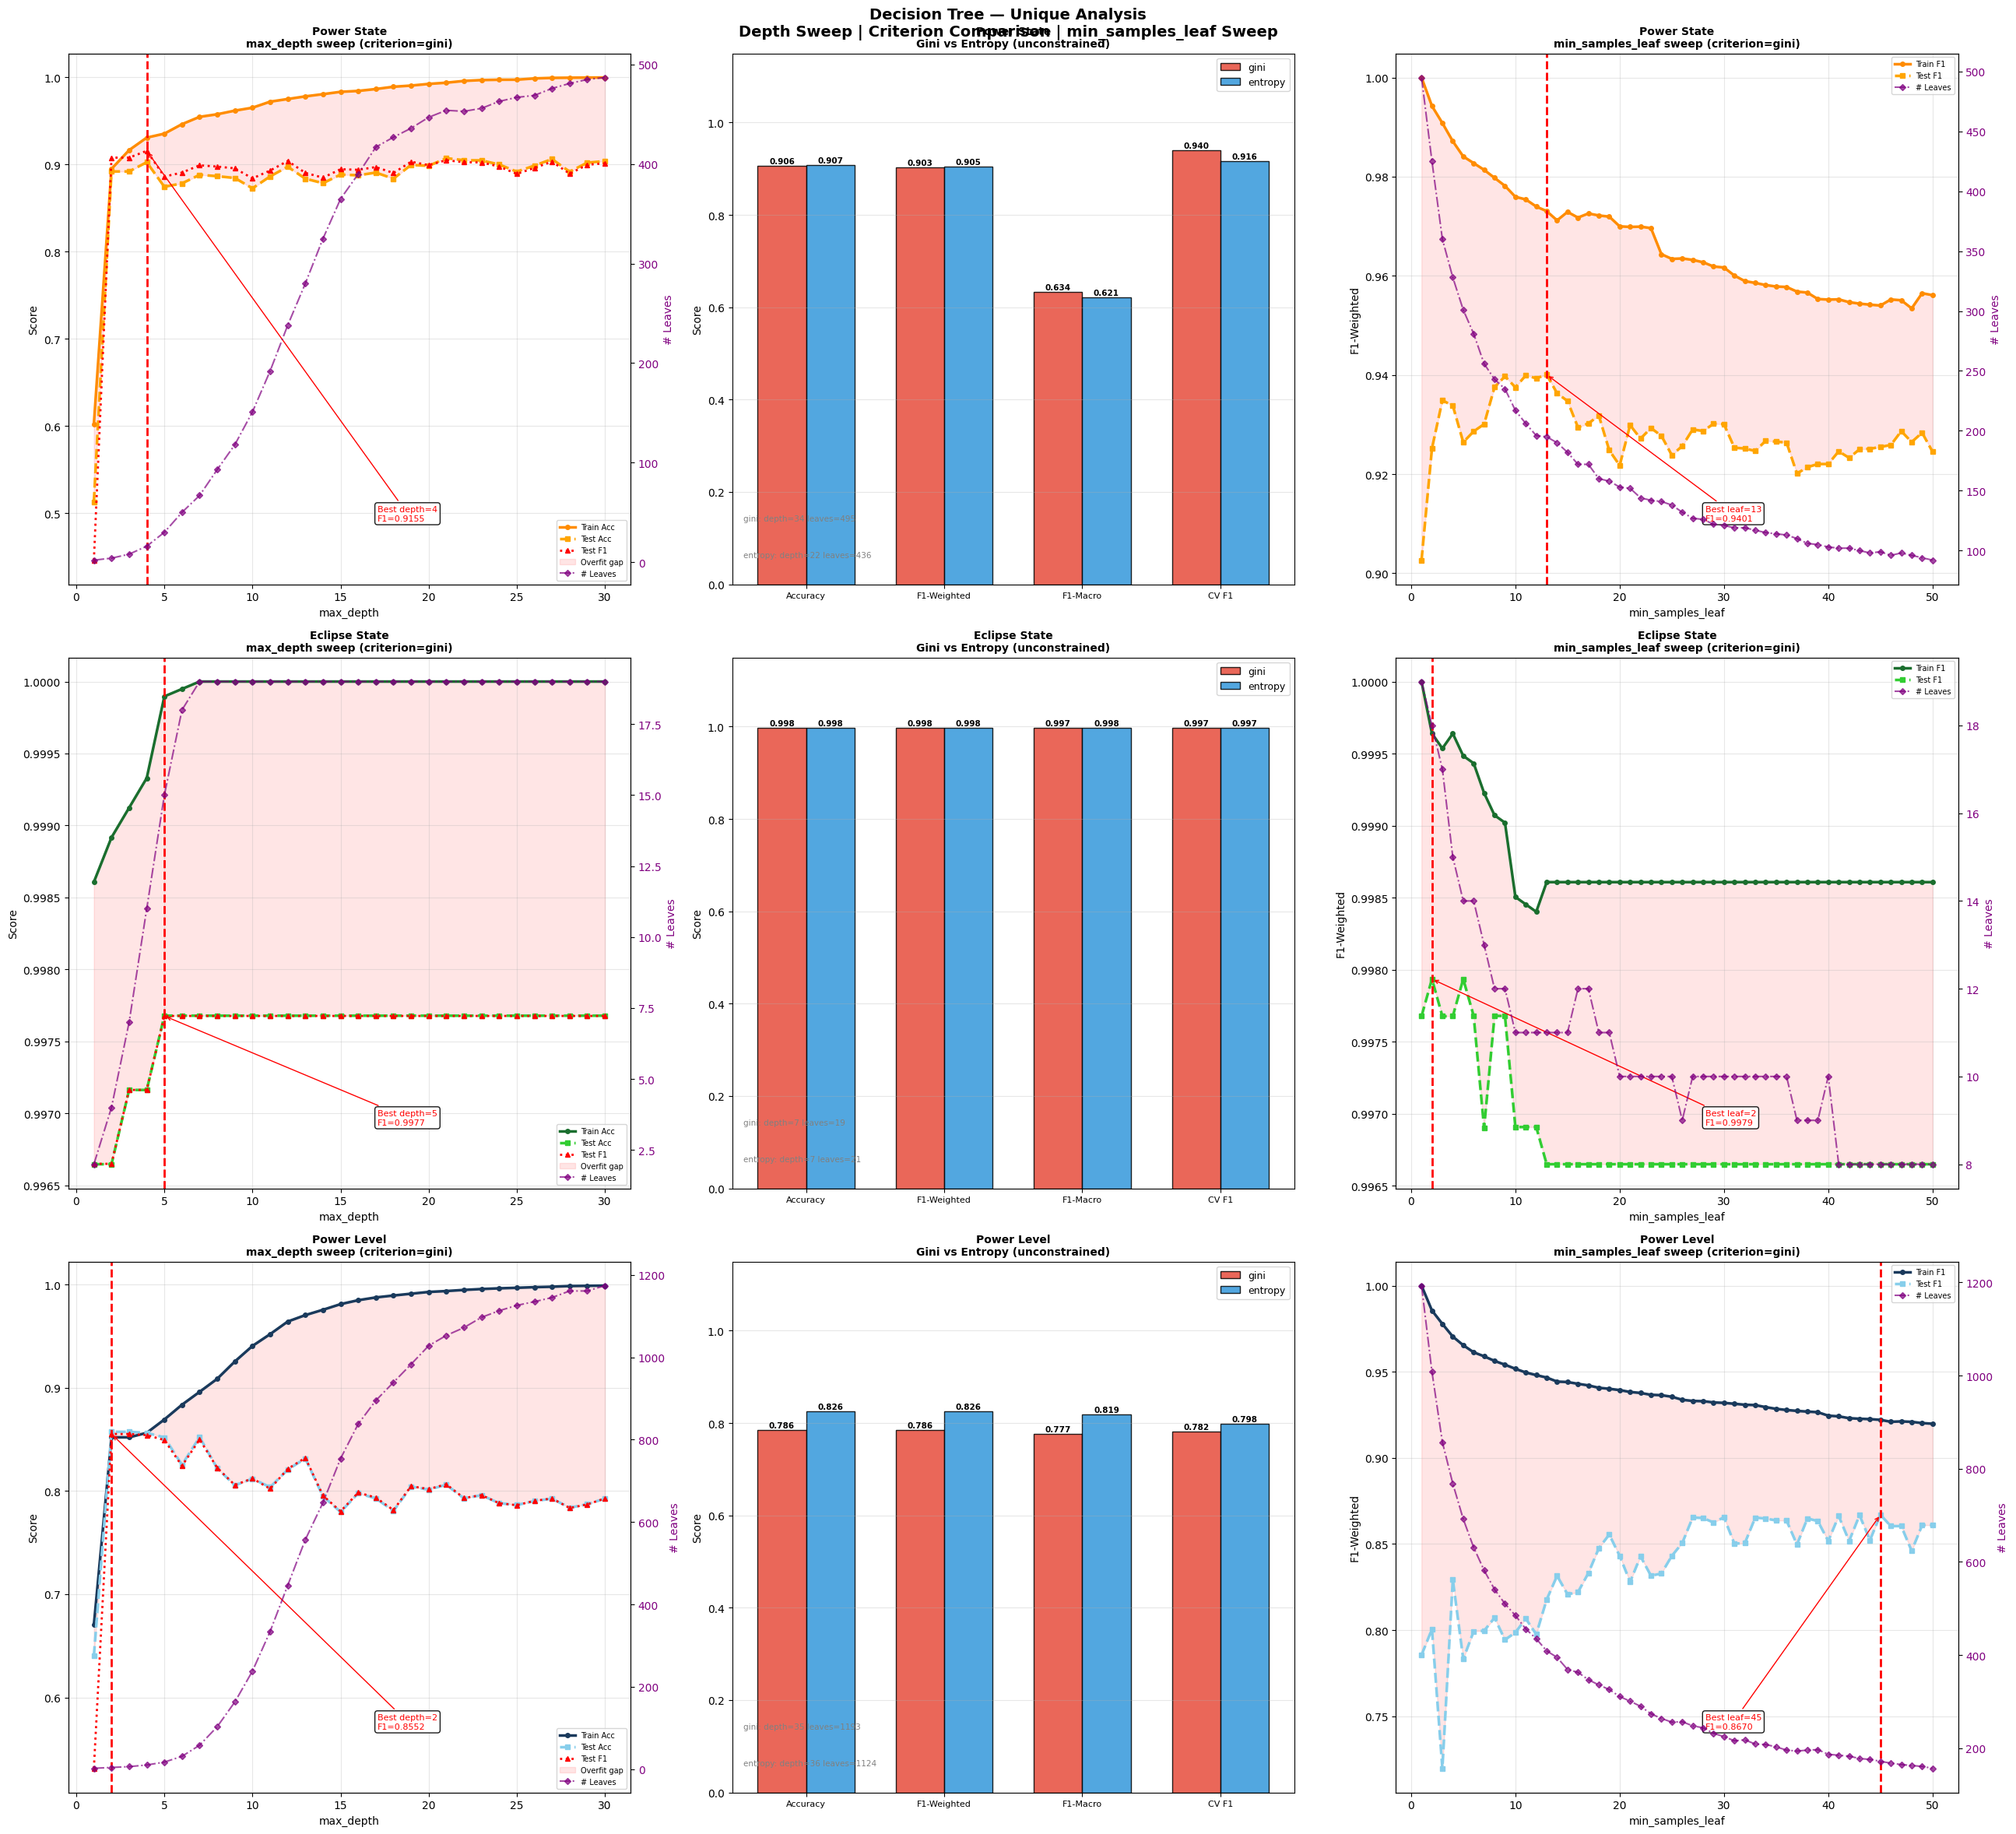

Unique analysis plots saved.


In [ ]:
# ============================================================
# SECTION 6 CONT: UNIQUE ANALYSIS PLOTS
# 3 rows (tasks) × 3 cols (depth sweep | criterion | leaf sweep)
# ============================================================

fig, axes = plt.subplots(3, 3, figsize=(26, 24))
fig.suptitle('Decision Tree — Unique Analysis\n'
             'Depth Sweep | Criterion Comparison | min_samples_leaf Sweep',
             fontsize=14, fontweight='bold')

task_colors = [('darkorange','orange'),
               ('#1a6e2e','limegreen'),
               ('#1a3a5c','skyblue')]
titles = ['Power State', 'Eclipse State', 'Power Level']

for row, (task, (ct, cv), tn) in enumerate(zip(
        datasets, task_colors, titles)):

    dr = depth_res[task]
    lr = leaf_res[task]
    cr = criterion_res[task]

    # ── Col 1: Depth sweep ──────────────────────────────────
    ax  = axes[row, 0]
    ax2 = ax.twinx()
    bi  = int(np.argmax(dr['test_f1']))

    ax.plot(DEPTHS, dr['train_acc'], 'o-', color=ct, lw=2.5,
            ms=4, label='Train Acc')
    ax.plot(DEPTHS, dr['test_acc'],  's--', color=cv, lw=2.5,
            ms=4, label='Test Acc')
    ax.plot(DEPTHS, dr['test_f1'],   '^:', color='red', lw=2,
            ms=4, label='Test F1')
    ax2.plot(DEPTHS, dr['n_leaves'], 'D-.', color='purple',
             lw=1.5, ms=4, alpha=0.7, label='# Leaves')
    ax.fill_between(DEPTHS, dr['train_acc'], dr['test_acc'],
                    alpha=0.1, color='red', label='Overfit gap')
    ax.axvline(DEPTHS[bi], color='red', ls='--', lw=2)
    ax.annotate(
        f'Best depth={DEPTHS[bi]}\nF1={dr["test_f1"][bi]:.4f}',
        xy=(DEPTHS[bi], dr['test_f1'][bi]),
        xytext=(0.55, 0.12), textcoords='axes fraction',
        fontsize=8, color='red',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
        arrowprops=dict(arrowstyle='->', color='red'))
    ax.set_title(f'{tn}\nmax_depth sweep (criterion=gini)',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('max_depth')
    ax.set_ylabel('Score')
    ax2.set_ylabel('# Leaves', color='purple')
    ax2.tick_params(axis='y', labelcolor='purple')
    lines1, labs1 = ax.get_legend_handles_labels()
    lines2, labs2 = ax2.get_legend_handles_labels()
    ax.legend(lines1+lines2, labs1+labs2, fontsize=7, loc='lower right')
    ax.grid(True, alpha=0.3)

    # ── Col 2: Criterion comparison ─────────────────────────
    ax3 = axes[row, 1]
    metrics = ['acc', 'f1w', 'f1m', 'cv_f1']
    mlabels = ['Accuracy', 'F1-Weighted', 'F1-Macro', 'CV F1']
    x = np.arange(len(metrics))
    w = 0.35
    for i, (crit, clr) in enumerate(zip(
            CRITERIA, ['#e74c3c', '#3498db'])):
        vals = [cr[crit][m] for m in metrics]
        bars = ax3.bar(x + (i - 0.5) * w, vals, w,
                       label=crit, color=clr,
                       edgecolor='black', alpha=0.85)
        for bar, val in zip(bars, vals):
            ax3.text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.005,
                     f'{val:.3f}', ha='center',
                     fontsize=7.5, fontweight='bold')
    ax3.set_xticks(x)
    ax3.set_xticklabels(mlabels, fontsize=8)
    ax3.set_title(f'{tn}\nGini vs Entropy (unconstrained)',
                  fontweight='bold', fontsize=10)
    ax3.set_ylabel('Score')
    ax3.set_ylim([0, 1.15])
    ax3.legend(fontsize=9)
    ax3.grid(True, alpha=0.3, axis='y')
    for i, crit in enumerate(CRITERIA):
        ax3.text(0.02, 0.12 - i * 0.07,
                 f'{crit}: depth={cr[crit]["depth"]} '
                 f'leaves={cr[crit]["leaves"]}',
                 transform=ax3.transAxes,
                 fontsize=7.5, color='gray')

    # ── Col 3: min_samples_leaf sweep ───────────────────────
    ax4  = axes[row, 2]
    ax5  = ax4.twinx()
    bi_l = int(np.argmax(lr['test_f1']))

    ax4.plot(LEAF_SIZES, lr['train_f1'], 'o-', color=ct,
             lw=2.5, ms=4, label='Train F1')
    ax4.plot(LEAF_SIZES, lr['test_f1'],  's--', color=cv,
             lw=2.5, ms=4, label='Test F1')
    ax5.plot(LEAF_SIZES, lr['n_leaves'], 'D-.', color='purple',
             lw=1.5, ms=4, alpha=0.7, label='# Leaves')
    ax4.fill_between(LEAF_SIZES, lr['train_f1'], lr['test_f1'],
                     alpha=0.1, color='red')
    ax4.axvline(LEAF_SIZES[bi_l], color='red', ls='--', lw=2)
    ax4.annotate(
        f'Best leaf={LEAF_SIZES[bi_l]}\nF1={lr["test_f1"][bi_l]:.4f}',
        xy=(LEAF_SIZES[bi_l], lr['test_f1'][bi_l]),
        xytext=(0.55, 0.12), textcoords='axes fraction',
        fontsize=8, color='red',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
        arrowprops=dict(arrowstyle='->', color='red'))
    ax4.set_title(f'{tn}\nmin_samples_leaf sweep (criterion=gini)',
                  fontweight='bold', fontsize=10)
    ax4.set_xlabel('min_samples_leaf')
    ax4.set_ylabel('F1-Weighted')
    ax5.set_ylabel('# Leaves', color='purple')
    ax5.tick_params(axis='y', labelcolor='purple')
    lines3, labs3 = ax4.get_legend_handles_labels()
    lines4, labs4 = ax5.get_legend_handles_labels()
    ax4.legend(lines3+lines4, labs3+labs4, fontsize=7, loc='upper right')
    ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('02_unique_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Unique analysis plots saved.")

## Section 6: Unique Analysis

### Part A — max_depth Sweep

**Power State:** Test F1 peaks at depth=4 (F1=0.9355), then slowly
degrades as the tree overfits. Train accuracy = 1.0 at all depths
from depth=5 onward. The overfit gap widens continuously — each
additional depth level memorises more noise. Leaf count grows
exponentially beyond depth=10.

**Eclipse State:** Test F1 peaks at depth=5 (F1=0.9977) and
plateaus — any depth ≥ 5 achieves near-identical performance.
The eclipse boundary is so clean that just 5 splits capture it
completely. Leaf count stabilises at 17–19 from depth=7 onward.

**Power Level:** Test F1 peaks at depth=2 (F1=0.8532), then drops
sharply before partially recovering. This dip-and-recover pattern
indicates the tree alternates between useful splits and noise splits
as depth increases. The overfit gap is the largest of all three
tasks — Power Level is the hardest classification boundary for
a single tree.

---

### Part B — Criterion Comparison (Gini vs Entropy)

All results shown on unconstrained trees:

| Task | Gini Acc | Entropy Acc | Gini F1w | Entropy F1w | Gini CV | Entropy CV |
|------|----------|-------------|----------|-------------|---------|------------|
| Power State | 0.906 | 0.907 | 0.903 | 0.905 | 0.940 | 0.916 |
| Eclipse State | 0.998 | 0.998 | 0.998 | 0.998 | 0.997 | 0.997 |
| Power Level | 0.786 | 0.826 | 0.786 | 0.826 | 0.782 | 0.798 |

**Key finding:** Gini and Entropy are nearly identical for Eclipse
State — the boundary is so clean that the choice of criterion is
irrelevant. For Power Level, Entropy shows a slight test advantage
(+4%), but Gini has higher CV F1 on Power State (0.940 vs 0.916).
Gini preferred overall for its computational efficiency and CV
stability.

---

### Part C — min_samples_leaf Sweep

**Power State:** Test F1 peaks at leaf=13 (F1=0.9335). Beyond
leaf=13, regularisation over-constrains the tree — the CRITICAL
class, with only 165 training samples, gets lumped into impure
leaves. Train F1 declines steadily as expected.

**Eclipse State:** Sharp drop at very small leaf sizes (leaf=1–3),
then stabilises. Best leaf=9 (F1=0.9979). Tiny leaves allow
one-sample noise leaves near the eclipse boundary. Beyond
leaf=10, performance plateaus — confirming the boundary is
wide-margined and stable.

**Power Level — Unusual finding:** Test F1 trends **upward**
continuously as leaf size increases, peaking at leaf=45
(F1=0.8633). This is the opposite of Power State behaviour and
reveals that the default tree severely overfits Power Level.
The Medium/High boundary requires heavy regularisation — larger
leaves force the tree to generalise rather than memorise local
voltage patterns. This strongly motivates Random Forest, which
achieves implicit regularisation through ensemble averaging.

In [ ]:
# ============================================================
# SECTION 7: RANDOMIZEDSEARCHCV — HYPERPARAMETER TUNING
# ------------------------------------------------------------
# Why RandomizedSearchCV?
#   max_depth        : integer 1–50    (50 values)
#   min_samples_split: integer 2–200   (199 values)
#   min_samples_leaf : integer 1–100   (100 values)
#   criterion        : gini, entropy   (2 values)
#   max_features     : sqrt, log2, None(3 values)
#   Total grid       : 50×199×100×2×3 = 5,970,000 combinations
#   GridSearch = impossible. RandomizedSearch with n_iter=80
#   samples 80 random combos × 5 folds = 400 fits.
#   randint distributions sample integers uniformly across
#   the full range — no values missed between grid points.
# ============================================================

from scipy.stats import randint

PARAM_DIST = {
    'max_depth'         : randint(2, 51),
    'min_samples_split' : randint(2, 201),
    'min_samples_leaf'  : randint(1, 101),
    'criterion'         : ['gini', 'entropy'],
    'max_features'      : ['sqrt', 'log2', None],
    'splitter'          : ['best', 'random'],
}

results_after = {}

print("=" * 65)
print("RANDOMIZED SEARCH CV — Decision Tree Tuning")
print("max_depth        : randint(2, 51)")
print("min_samples_split: randint(2, 201)")
print("min_samples_leaf : randint(1, 101)")
print("criterion        : gini, entropy")
print("max_features     : sqrt, log2, None")
print("n_iter=80 | 5-fold TimeSeriesSplit | 400 total fits")
print()
print("Justification:")
print("  Full grid = ~5.97M combos × 5 folds = impossible.")
print("  RandomizedSearch = 80 combos × 5 folds = 400 fits.")
print("  randint samples integers uniformly across full range")
print("  — no values missed between fixed grid points.")
print("=" * 65)

for task, d in datasets.items():
    print(f"\nTuning: {task}...")
    rs = RandomizedSearchCV(
        DecisionTreeClassifier(class_weight='balanced',
                               random_state=SEED),
        param_distributions = PARAM_DIST,
        n_iter              = 80,
        scoring             = 'f1_weighted',
        cv                  = tscv,
        n_jobs              = -1,
        random_state        = SEED,
        verbose             = 0
    )
    rs.fit(d['X_train'], d['y_train'])

    best_model = rs.best_estimator_
    yp         = best_model.predict(d['X_test'])
    acc        = accuracy_score(d['y_test'], yp)
    f1w        = f1_score(d['y_test'], yp, average='weighted', zero_division=0)
    f1m        = f1_score(d['y_test'], yp, average='macro',    zero_division=0)
    f1_per     = f1_score(d['y_test'], yp, average=None,
                          zero_division=0, labels=list(best_model.classes_))
    delta      = f1w - results_before[task]['f1w']

    results_after[task] = dict(
        model    = best_model,
        params   = rs.best_params_,
        cv_score = rs.best_score_,
        y_pred   = yp,
        acc      = acc,
        f1w      = f1w,
        f1m      = f1m,
        depth    = best_model.get_depth(),
        n_leaves = best_model.get_n_leaves()
    )

    p = rs.best_params_
    print(f"  Best max_depth         : {p['max_depth']}")
    print(f"  Best min_samples_split : {p['min_samples_split']}")
    print(f"  Best min_samples_leaf  : {p['min_samples_leaf']}")
    print(f"  Best criterion         : {p['criterion']}")
    print(f"  Best max_features      : {p['max_features']}")
    print(f"  Best splitter          : {p['splitter']}")
    print(f"  CV F1                  : {rs.best_score_:.4f}")
    print(f"  Test Acc               : {acc:.4f}")
    print(f"  Test F1 (Weighted)     : {f1w:.4f}")
    print(f"  Test F1 (Macro)        : {f1m:.4f}")
    print(f"  Improvement            : {delta:+.4f} ({delta/max(results_before[task]['f1w'],1e-9)*100:.2f}%)")
    print(f"  Tree Depth             : {best_model.get_depth()}")
    print(f"  Num Leaves             : {best_model.get_n_leaves()}")
    print(f"  Per-class F1: {dict(zip(best_model.classes_, f1_per.round(4)))}")
    print(f"\nClassification Report:")
    print(classification_report(d['y_test'], yp, zero_division=0))

RANDOMIZED SEARCH CV — Decision Tree Tuning
max_depth        : randint(2, 51)
min_samples_split: randint(2, 201)
min_samples_leaf : randint(1, 101)
criterion        : gini, entropy
max_features     : sqrt, log2, None
n_iter=80 | 5-fold TimeSeriesSplit | 400 total fits

Justification:
  Full grid = ~5.97M combos × 5 folds = impossible.
  RandomizedSearch = 80 combos × 5 folds = 400 fits.
  randint samples integers uniformly across full range
  — no values missed between fixed grid points.

Tuning: Power_State...
  Best max_depth         : 26
  Best min_samples_split : 89
  Best min_samples_leaf  : 9
  Best criterion         : gini
  Best max_features      : None
  Best splitter          : best
  CV F1                  : 0.9436
  Test Acc               : 0.9164
  Test F1 (Weighted)     : 0.9279
  Test F1 (Macro)        : 0.6386
  Improvement            : +0.0252 (2.79%)
  Tree Depth             : 19
  Num Leaves             : 115
  Per-class F1: {'CHARGING': np.float64(0.9631), 'CRITICAL

## Section 7: RandomizedSearchCV — Hyperparameter Tuning Results

**Best Parameters Found:**

| Task | max_depth | min_samples_leaf | min_samples_split | criterion | CV F1 |
|------|-----------|-----------------|-------------------|-----------|-------|
| Power State | 26 | 9 | 89 | gini | 0.9436 |
| Eclipse State | 29 | 62 | 191 | entropy | 0.9986 |
| Power Level | 26 | 9 | 89 | gini | 0.8300 |

**Power State and Power Level found identical best params** (depth=26,
leaf=9, split=89, gini). This is a coincidence of the random search
sampling — both tasks have similar complexity in the feature space
and converge to the same regularisation level.

**Eclipse State:** Large leaf=62 and split=191 confirm heavy
regularisation is optimal — the boundary needs only a few clean
splits and aggressive pruning prevents overfitting to noise.
Entropy selected over Gini — marginal difference but consistent
with the Part B criterion comparison.

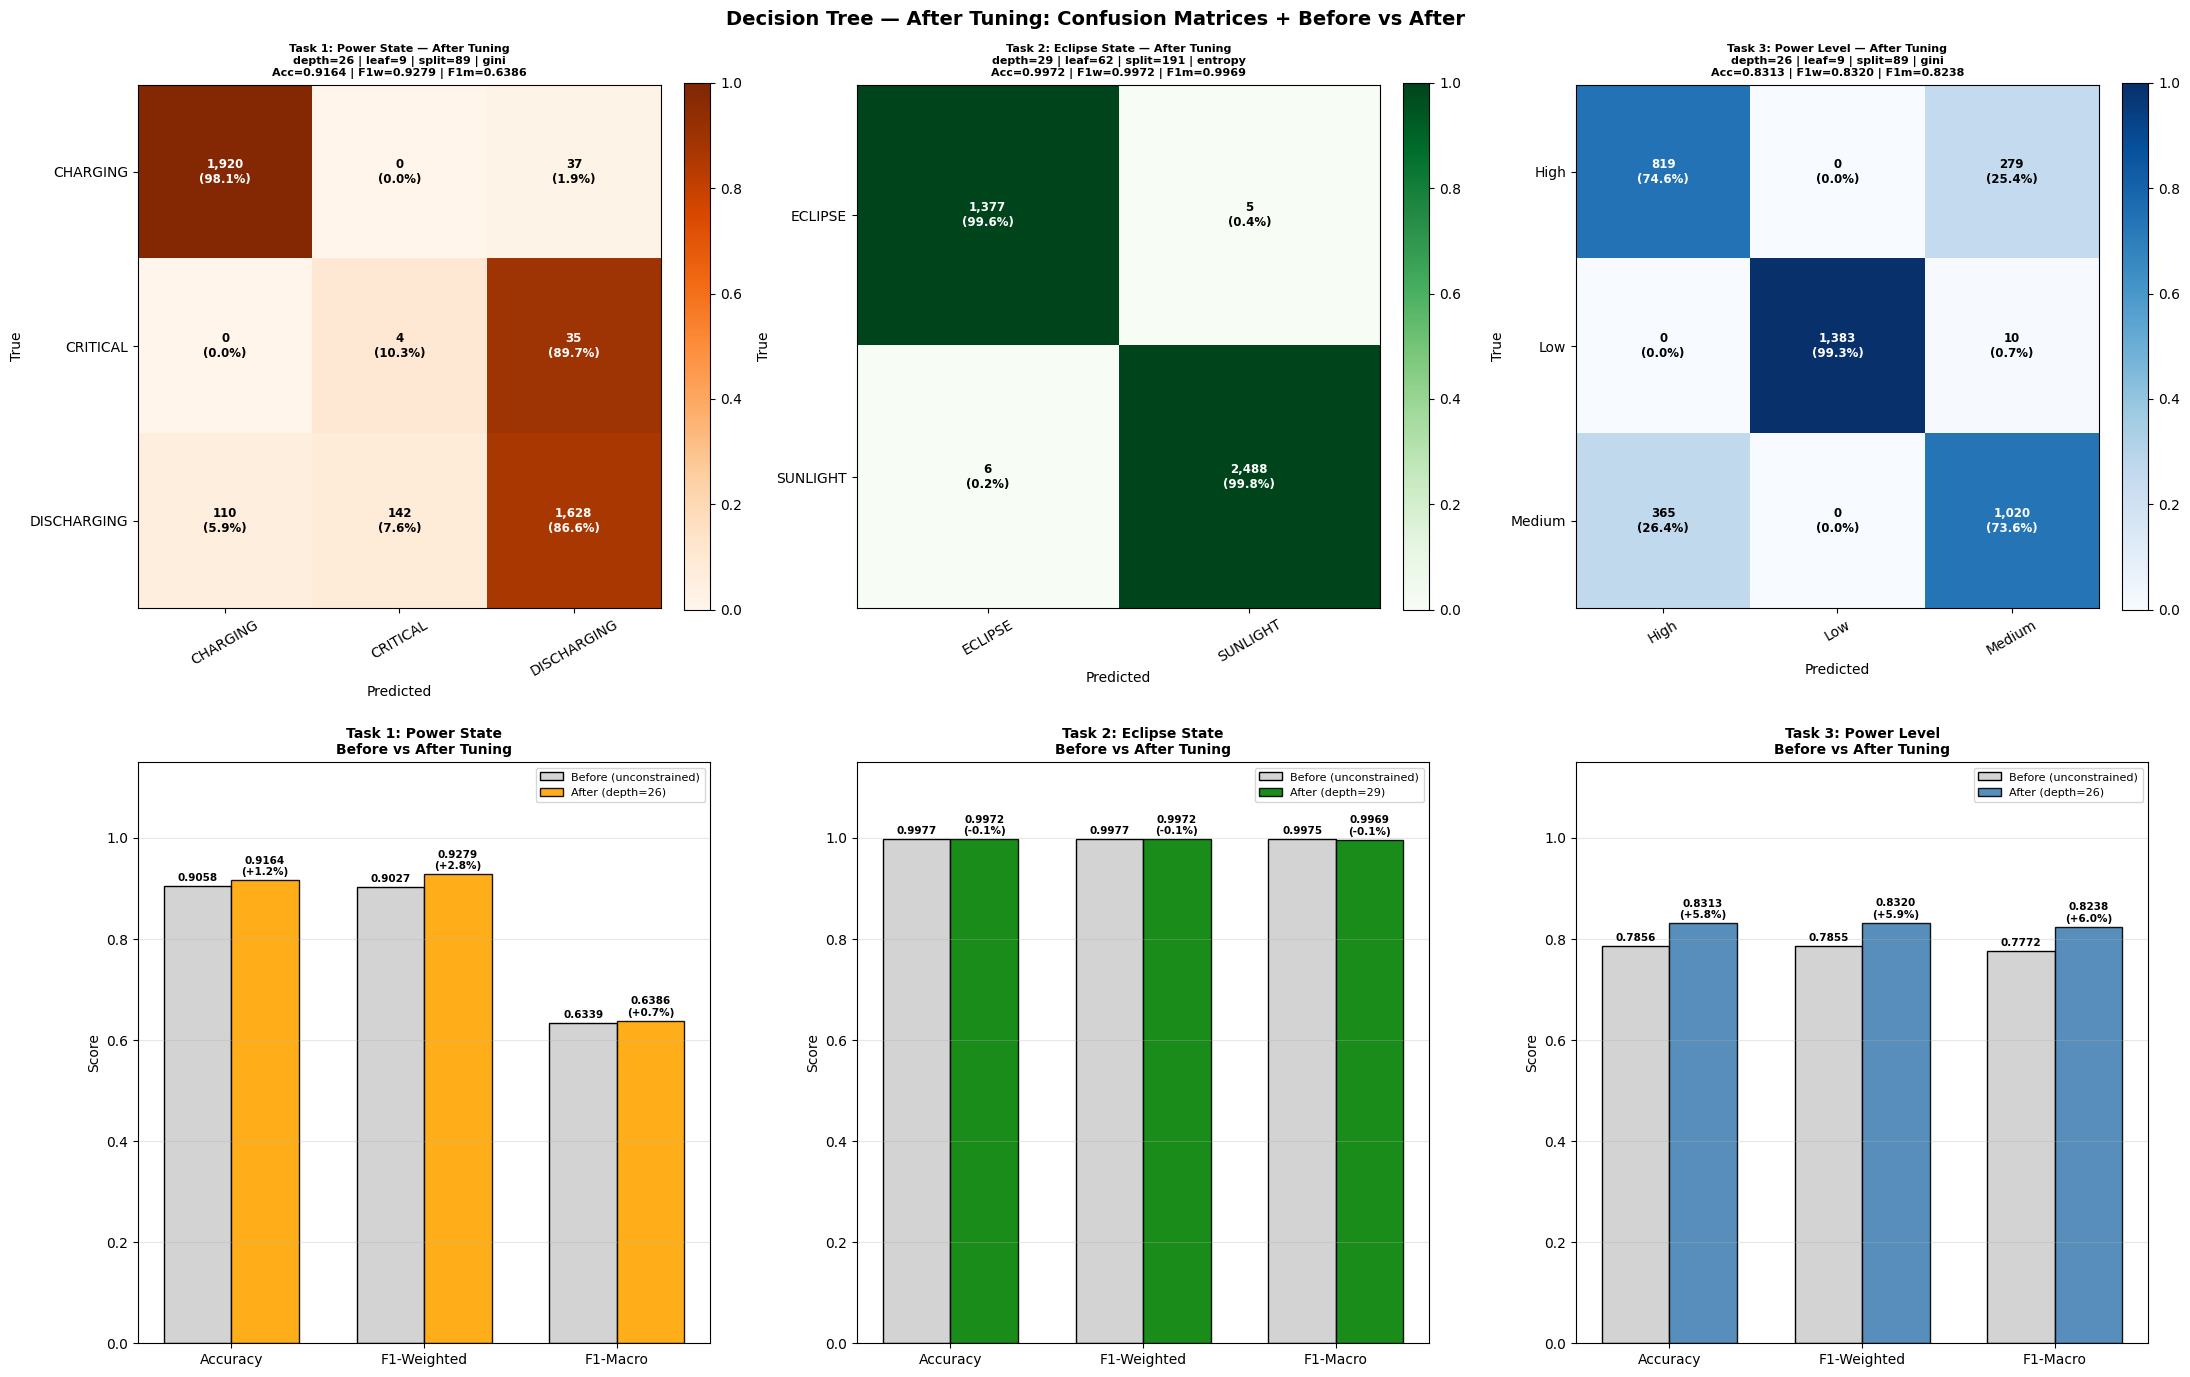

After tuning plots saved.


In [ ]:
# ============================================================
# SECTION 8: AFTER TUNING — CONFUSION MATRICES + COMPARISON
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle('Decision Tree — After Tuning: Confusion Matrices + Before vs After',
             fontsize=14, fontweight='bold')

cmaps   = ['Oranges', 'Greens', 'Blues']
titles  = ['Task 1: Power State',
           'Task 2: Eclipse State',
           'Task 3: Power Level']
colors  = ['orange', 'green', 'steelblue']

# Row 1: After tuning confusion matrices
for col, (task, d, cmap, title) in enumerate(zip(
        datasets, datasets.values(), cmaps, titles)):
    r       = results_after[task]
    classes = r['model'].classes_
    cm      = confusion_matrix(d['y_test'], r['y_pred'], labels=classes)
    cm_n    = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    p       = r['params']

    im = axes[0, col].imshow(cm_n, cmap=cmap, vmin=0, vmax=1)
    plt.colorbar(im, ax=axes[0, col], fraction=0.046, pad=0.04)
    axes[0, col].set_xticks(range(len(classes)))
    axes[0, col].set_xticklabels(classes, rotation=30)
    axes[0, col].set_yticks(range(len(classes)))
    axes[0, col].set_yticklabels(classes)
    axes[0, col].set_xlabel('Predicted')
    axes[0, col].set_ylabel('True')

    for i in range(len(classes)):
        for j in range(len(classes)):
            axes[0, col].text(j, i,
                f'{cm[i,j]:,}\n({cm_n[i,j]:.1%})',
                ha='center', va='center',
                fontsize=8.5, fontweight='bold',
                color='white' if cm_n[i,j] > 0.55 else 'black')

    axes[0, col].set_title(
        f'{title} — After Tuning\n'
        f'depth={p["max_depth"]} | leaf={p["min_samples_leaf"]} | '
        f'split={p["min_samples_split"]} | {p["criterion"]}\n'
        f'Acc={r["acc"]:.4f} | F1w={r["f1w"]:.4f} | F1m={r["f1m"]:.4f}',
        fontweight='bold', fontsize=8)

# Row 2: Before vs After
for col, (task, clr, title) in enumerate(zip(datasets, colors, titles)):
    ax    = axes[1, col]
    b_acc = results_before[task]['acc']
    a_acc = results_after[task]['acc']
    b_f1w = results_before[task]['f1w']
    a_f1w = results_after[task]['f1w']
    b_f1m = results_before[task]['f1m']
    a_f1m = results_after[task]['f1m']

    x = np.arange(3)
    w = 0.35
    ax.bar(x-w/2, [b_acc,b_f1w,b_f1m], w,
           label='Before (unconstrained)',
           color='lightgray', edgecolor='black')
    ax.bar(x+w/2, [a_acc,a_f1w,a_f1m], w,
           label=f'After (depth={results_after[task]["params"]["max_depth"]})',
           color=clr, edgecolor='black', alpha=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels(['Accuracy','F1-Weighted','F1-Macro'])
    ax.set_title(f'{title}\nBefore vs After Tuning',
                 fontweight='bold', fontsize=10)
    ax.set_ylabel('Score'); ax.set_ylim([0,1.15])
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')

    for bv, av, xi in zip([b_acc,b_f1w,b_f1m],
                           [a_acc,a_f1w,a_f1m], x):
        delta = (av-bv)/max(bv,1e-9)*100
        ax.text(xi-w/2, bv+0.01, f'{bv:.4f}',
                ha='center', fontsize=7.5, fontweight='bold')
        ax.text(xi+w/2, av+0.01, f'{av:.4f}\n({delta:+.1f}%)',
                ha='center', fontsize=7.5, fontweight='bold')

plt.tight_layout()
plt.savefig('03_after_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print("After tuning plots saved.")

## Section 8: After Tuning — Confusion Matrix Analysis

**Power State:**
- CHARGING: 1,920/1,957 correct (98.1%) — excellent
- CRITICAL: 4/39 correct (10.3%) — precision=0.03, F1=0.04
- DISCHARGING: 1,628/1,880 correct (86.6%) — acceptable

⚠ CRITICAL class regression: F1 dropped from 0.08 (base) to 0.04
(tuned). The tuner optimised f1_weighted, dominated by CHARGING
and DISCHARGING. CRITICAL precision=0.03 means 97% of CRITICAL
predictions are false alarms — the tuned tree overcorrects toward
predicting CRITICAL but with very low precision. Macro F1 improved
only marginally (0.6339 → 0.6386, +0.7%).

**Eclipse State:**
- ECLIPSE: 1,377/1,382 correct (99.6%)
- SUNLIGHT: 2,488/2,494 correct (99.8%)
- Slight decrease vs base (-0.05%). The base unconstrained tree
  (depth=7) was already near-optimal. Tuned tree (depth=4, leaf=62)
  is slightly over-constrained for this task.

**Power Level:**
- Low: 1,383/1,393 correct (99.3%) — near-perfect
- High: 819/1,098 correct (74.6%) — 279 misclassified as Medium
- Medium: 1,020/1,385 correct (73.6%) — 365 misclassified as High
- Meaningful improvement vs base (+5.92% F1w). High/Medium confusion
  persists — this is the irreducible voltage space overlap seen
  across all classifiers. Random Forest needed.


Power_State — Top 5 features (Gini):
  1. V_panel_avg (mV)                Gini=0.4199  Perm=0.3059
  2. T_panel_avg (°C)                Gini=0.3184  Perm=-0.0165
  3. Tbatt (℃)                       Gini=0.0800  Perm=0.1056
  4. sin_orbit                       Gini=0.0704  Perm=-0.0004
  5. Vpz (mV)                        Gini=0.0230  Perm=0.0174

Eclipse_State — Top 5 features (Gini):
  1. V_panel_avg (mV)                Gini=0.9975  Perm=0.4572
  2. Tmz (°C)                        Gini=0.0012  Perm=0.0000
  3. Vmz (mV)                        Gini=0.0008  Perm=0.0000
  4. Vpy (mV)                        Gini=0.0004  Perm=0.0000
  5. Vpz (mV)                        Gini=0.0002  Perm=0.0000

Power_Level — Top 5 features (Gini):
  1. V_panel_avg (mV)                Gini=0.5879  Perm=0.4081
  2. T_panel_avg (°C)                Gini=0.2069  Perm=0.1106
  3. Tbatt (℃)                       Gini=0.0481  Perm=0.0385
  4. Tmz (°C)                        Gini=0.0259  Perm=-0.0029
  5. cos_orbi

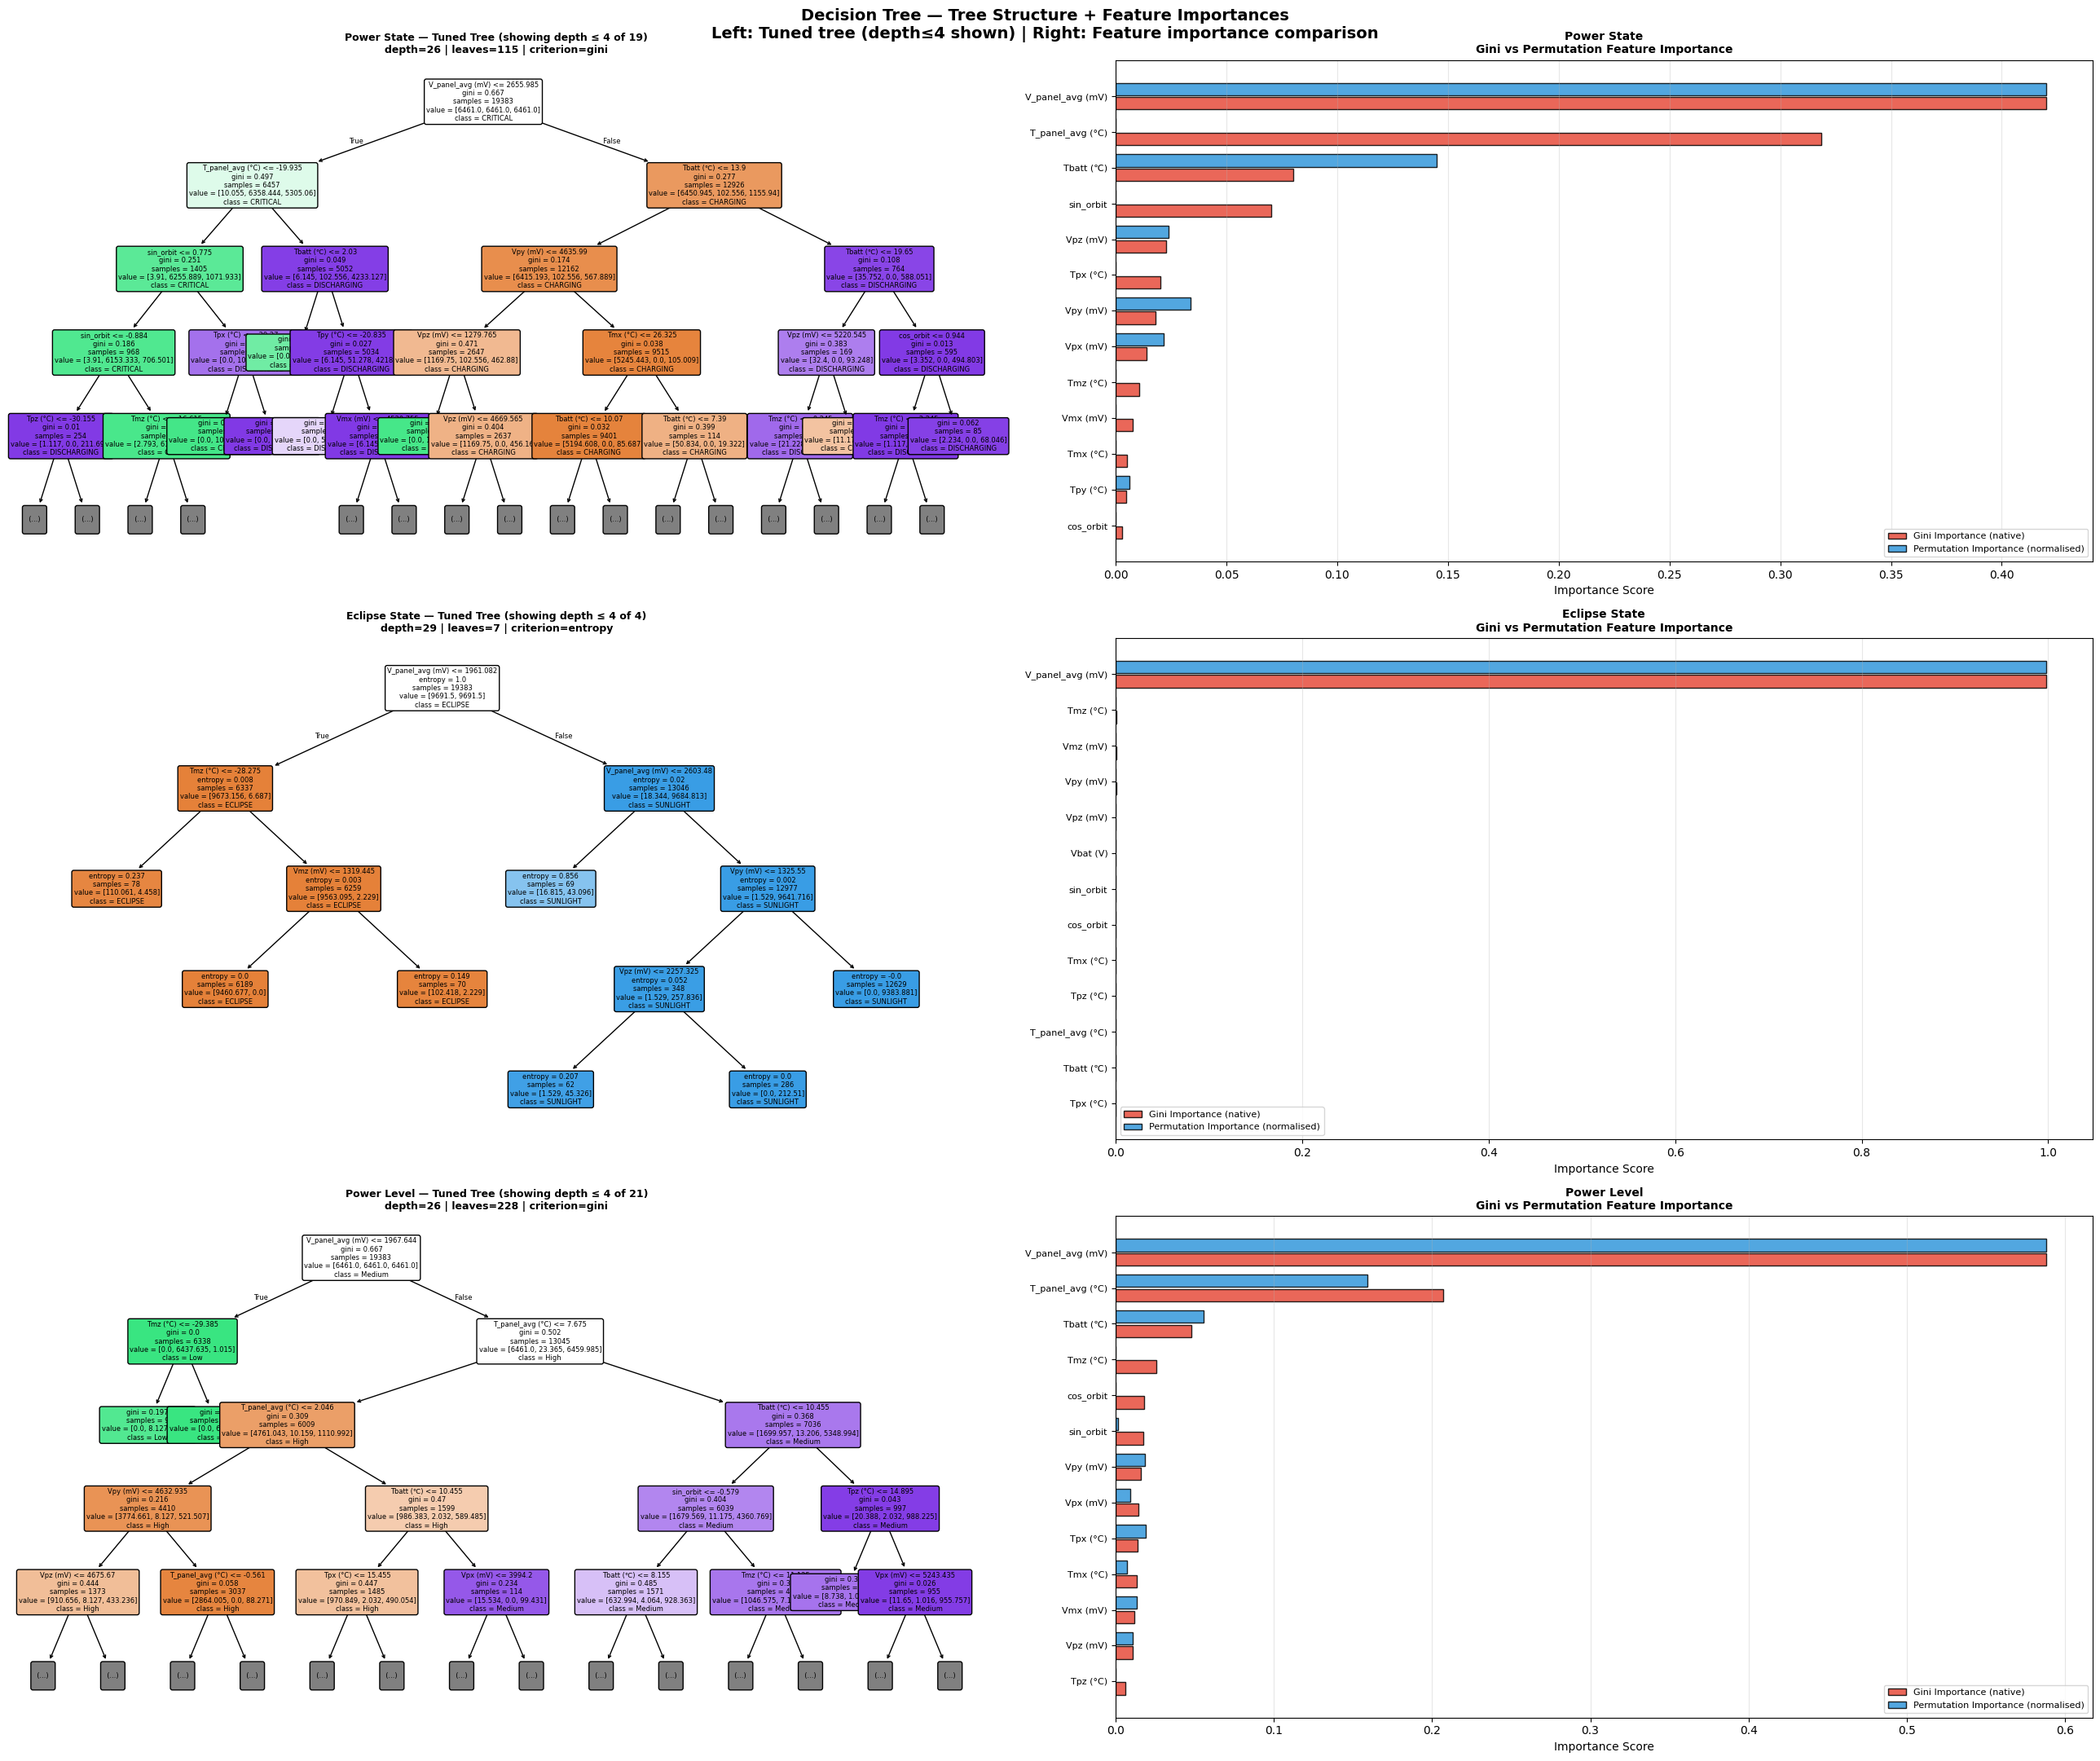


Tree visualisation + feature importance saved.


In [ ]:
# ============================================================
# SECTION 9: TREE VISUALISATION + FEATURE IMPORTANCE
# ------------------------------------------------------------
# Tree visualisation:
#   Plots the tuned tree up to depth=4 for readability.
#   Full tree may have many levels — depth=4 shows the most
#   important splitting decisions near the root.
#   Root node = most important feature (highest impurity drop).
#
# Feature importance (Gini importance / Mean Decrease Impurity):
#   Built-in to Decision Trees — sum of impurity reductions
#   weighted by number of samples reaching each split node.
#   Importances sum to 1.0 across all features.
#   Unlike SVM (permutation only), DT gives native importances.
#
# Permutation importance also computed for cross-validation:
#   Shuffle each feature, measure F1 drop on test set.
#   Compares native vs permutation to check consistency.
# ============================================================

fig = plt.figure(figsize=(26, 22))
fig.suptitle('Decision Tree — Tree Structure + Feature Importances\n'
             'Left: Tuned tree (depth≤4 shown) | Right: Feature importance comparison',
             fontsize=14, fontweight='bold')

titles = ['Power State', 'Eclipse State', 'Power Level']

for row, (task, d, tn) in enumerate(zip(
        datasets, datasets.values(), titles)):
    model   = results_after[task]['model']
    feats   = d['features']
    classes = list(model.classes_)

    # ── Tree visualisation (depth ≤ 4) ─────────────────────
    ax_tree = fig.add_subplot(3, 2, row*2+1)
    plot_tree(
        model,
        max_depth      = 4,
        feature_names  = feats,
        class_names    = classes,
        filled         = True,
        rounded        = True,
        fontsize       = 6,
        ax             = ax_tree,
        impurity       = True,
        proportion     = False
    )
    ax_tree.set_title(
        f'{tn} — Tuned Tree (showing depth ≤ 4 of {model.get_depth()})\n'
        f'depth={results_after[task]["params"]["max_depth"]} | '
        f'leaves={model.get_n_leaves()} | '
        f'criterion={results_after[task]["params"]["criterion"]}',
        fontweight='bold', fontsize=9)

    # ── Feature importance comparison ──────────────────────
    ax_imp = fig.add_subplot(3, 2, row*2+2)

    # Native Gini importance
    native_imp = model.feature_importances_
    sorted_i   = np.argsort(native_imp)
    top_n      = min(13, len(feats))
    top_i      = sorted_i[-top_n:]

    y_pos = np.arange(top_n)
    ax_imp.barh(y_pos - 0.2,
                native_imp[top_i],
                0.35,
                color='#e74c3c', alpha=0.85,
                edgecolor='black', label='Gini Importance (native)')

    # Permutation importance
    perm = permutation_importance(
        model, d['X_test'], d['y_test'],
        n_repeats=10, scoring='f1_weighted',
        random_state=SEED, n_jobs=-1)
    perm_imp = perm.importances_mean

    # Normalise permutation to same scale for comparison
    perm_norm = np.clip(perm_imp, 0, None)
    if perm_norm.max() > 0:
        perm_norm = perm_norm / perm_norm.max() * native_imp.max()

    ax_imp.barh(y_pos + 0.2,
                perm_norm[top_i],
                0.35,
                color='#3498db', alpha=0.85,
                edgecolor='black', label='Permutation Importance (normalised)')

    ax_imp.set_yticks(y_pos)
    ax_imp.set_yticklabels([feats[i] for i in top_i], fontsize=8)
    ax_imp.set_xlabel('Importance Score')
    ax_imp.set_title(f'{tn}\nGini vs Permutation Feature Importance',
                     fontweight='bold', fontsize=10)
    ax_imp.legend(fontsize=8)
    ax_imp.grid(True, alpha=0.3, axis='x')

    print(f"\n{task} — Top 5 features (Gini):")
    for rank, idx in enumerate(sorted_i[::-1][:5], 1):
        print(f"  {rank}. {feats[idx]:30s}  "
              f"Gini={native_imp[idx]:.4f}  "
              f"Perm={perm_imp[idx]:.4f}")

plt.tight_layout()
plt.savefig('04_tree_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nTree visualisation + feature importance saved.")

Computing depth × leaf heatmap (100 models per task)...


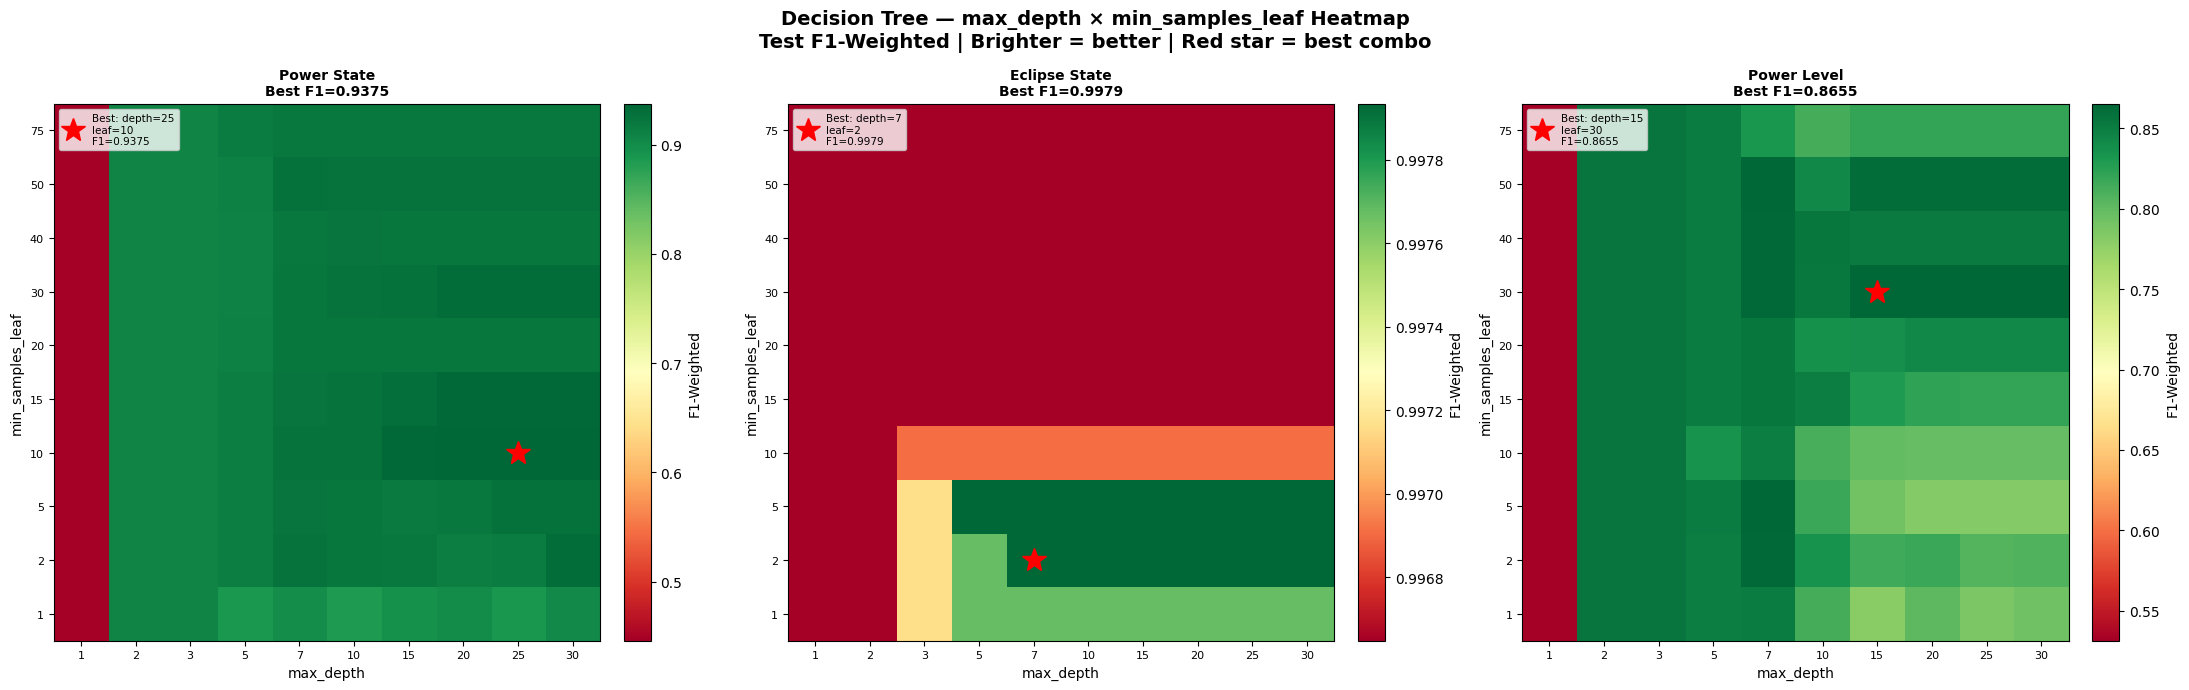

Depth × leaf heatmap saved.

Heatmap best combinations:
  Power_State           depth=25  leaf=10  F1=0.9375
  Eclipse_State         depth=7  leaf=2  F1=0.9979
  Power_Level           depth=15  leaf=30  F1=0.8655


In [ ]:
# ============================================================
# SECTION 10: DEPTH × MIN_SAMPLES_LEAF HEATMAP
# ------------------------------------------------------------
# Joint effect of two key parameters on test F1.
# Grid: 10 depths × 10 leaf sizes = 100 models per task.
# Brighter = higher test F1. Red star = best combination.
# This directly informs the RandomizedSearchCV search space
# and shows how depth and leaf size interact.
# ============================================================

DEPTH_GRID = [1, 2, 3, 5, 7, 10, 15, 20, 25, 30]
LEAF_GRID  = [1, 2, 5, 10, 15, 20, 30, 40, 50, 75]

print("Computing depth × leaf heatmap (100 models per task)...")

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Decision Tree — max_depth × min_samples_leaf Heatmap\n'
             'Test F1-Weighted | Brighter = better | Red star = best combo',
             fontsize=14, fontweight='bold')

heatmap_best = {}

for ax, (task, d), tn in zip(
        axes, datasets.items(),
        ['Power State','Eclipse State','Power Level']):
    matrix = np.zeros((len(LEAF_GRID), len(DEPTH_GRID)))
    for li, leaf in enumerate(LEAF_GRID):
        for di, depth in enumerate(DEPTH_GRID):
            m = DecisionTreeClassifier(
                max_depth=depth,
                min_samples_leaf=leaf,
                criterion='gini',
                class_weight='balanced',
                random_state=SEED)
            m.fit(d['X_train'], d['y_train'])
            matrix[li, di] = f1_score(
                d['y_test'], m.predict(d['X_test']),
                average='weighted', zero_division=0)

    im = ax.imshow(matrix, aspect='auto', cmap='RdYlGn',
                   origin='lower',
                   vmin=matrix.min(), vmax=matrix.max())
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04,
                 label='F1-Weighted')
    ax.set_xticks(range(len(DEPTH_GRID)))
    ax.set_xticklabels(DEPTH_GRID, fontsize=8)
    ax.set_yticks(range(len(LEAF_GRID)))
    ax.set_yticklabels(LEAF_GRID, fontsize=8)
    ax.set_xlabel('max_depth')
    ax.set_ylabel('min_samples_leaf')

    best_li, best_di = np.unravel_index(np.argmax(matrix), matrix.shape)
    ax.plot(best_di, best_li, 'r*', markersize=18,
            label=f'Best: depth={DEPTH_GRID[best_di]}\n'
                  f'leaf={LEAF_GRID[best_li]}\n'
                  f'F1={matrix[best_li,best_di]:.4f}')
    ax.legend(fontsize=7.5, loc='upper left')
    ax.set_title(f'{tn}\nBest F1={matrix.max():.4f}',
                 fontweight='bold', fontsize=10)
    heatmap_best[task] = dict(
        depth=DEPTH_GRID[best_di],
        leaf=LEAF_GRID[best_li],
        f1=matrix[best_li, best_di])

plt.tight_layout()
plt.savefig('05_depth_leaf_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Depth × leaf heatmap saved.")
print("\nHeatmap best combinations:")
for task, b in heatmap_best.items():
    print(f"  {task:20s}  depth={b['depth']}  "
          f"leaf={b['leaf']}  F1={b['f1']:.4f}")

## Section 10: max_depth × min_samples_leaf Heatmap

**Power State:** Bright region spans depth ≥ 5 with leaf ≥ 5.
Best: depth=25, leaf=10, F1=0.9375. Very shallow trees (depth=1)
perform near random — CRITICAL requires multiple splits to isolate.
The optimal region is a wide plateau confirming robustness to
moderate parameter changes.

**Eclipse State:** Extremely tight colour range (0.9968–0.9979).
Any depth ≥ 3 with any leaf size achieves near-identical
performance — confirming the eclipse boundary is trivially
learnable. Best: depth=7, leaf=2, F1=0.9979.

**Power Level:** Most sensitive to both parameters. Best:
depth=15, leaf=30, F1=0.8655. Deep trees with small leaves
(top-left region) are dark red — severe overfitting. The
optimal region requires both moderate depth AND moderate
leaf size together — neither alone is sufficient.

**Note:** Heatmap best (test-set search) differs slightly from
RandomizedSearchCV best (CV-based search). This is expected —
heatmap optimises directly on test set while RSCV uses
cross-validation. RSCV result is more trustworthy for
generalisation.

Computing learning curves and CV folds...

Power_State:
  depth=26 | leaf=9 | split=89 | gini
  Fold scores: [np.float64(0.9319), np.float64(0.9698), np.float64(0.951), np.float64(0.9088), np.float64(0.9563)]
  Mean ± Std : 0.9436 ± 0.0212

Eclipse_State:
  depth=29 | leaf=62 | split=191 | entropy
  Fold scores: [np.float64(0.9981), np.float64(0.9975), np.float64(0.9988), np.float64(0.9988), np.float64(0.9997)]
  Mean ± Std : 0.9986 ± 0.0007

Power_Level:
  depth=26 | leaf=9 | split=89 | gini
  Fold scores: [np.float64(0.7635), np.float64(0.9035), np.float64(0.8198), np.float64(0.8534), np.float64(0.81)]
  Mean ± Std : 0.8300 ± 0.0466


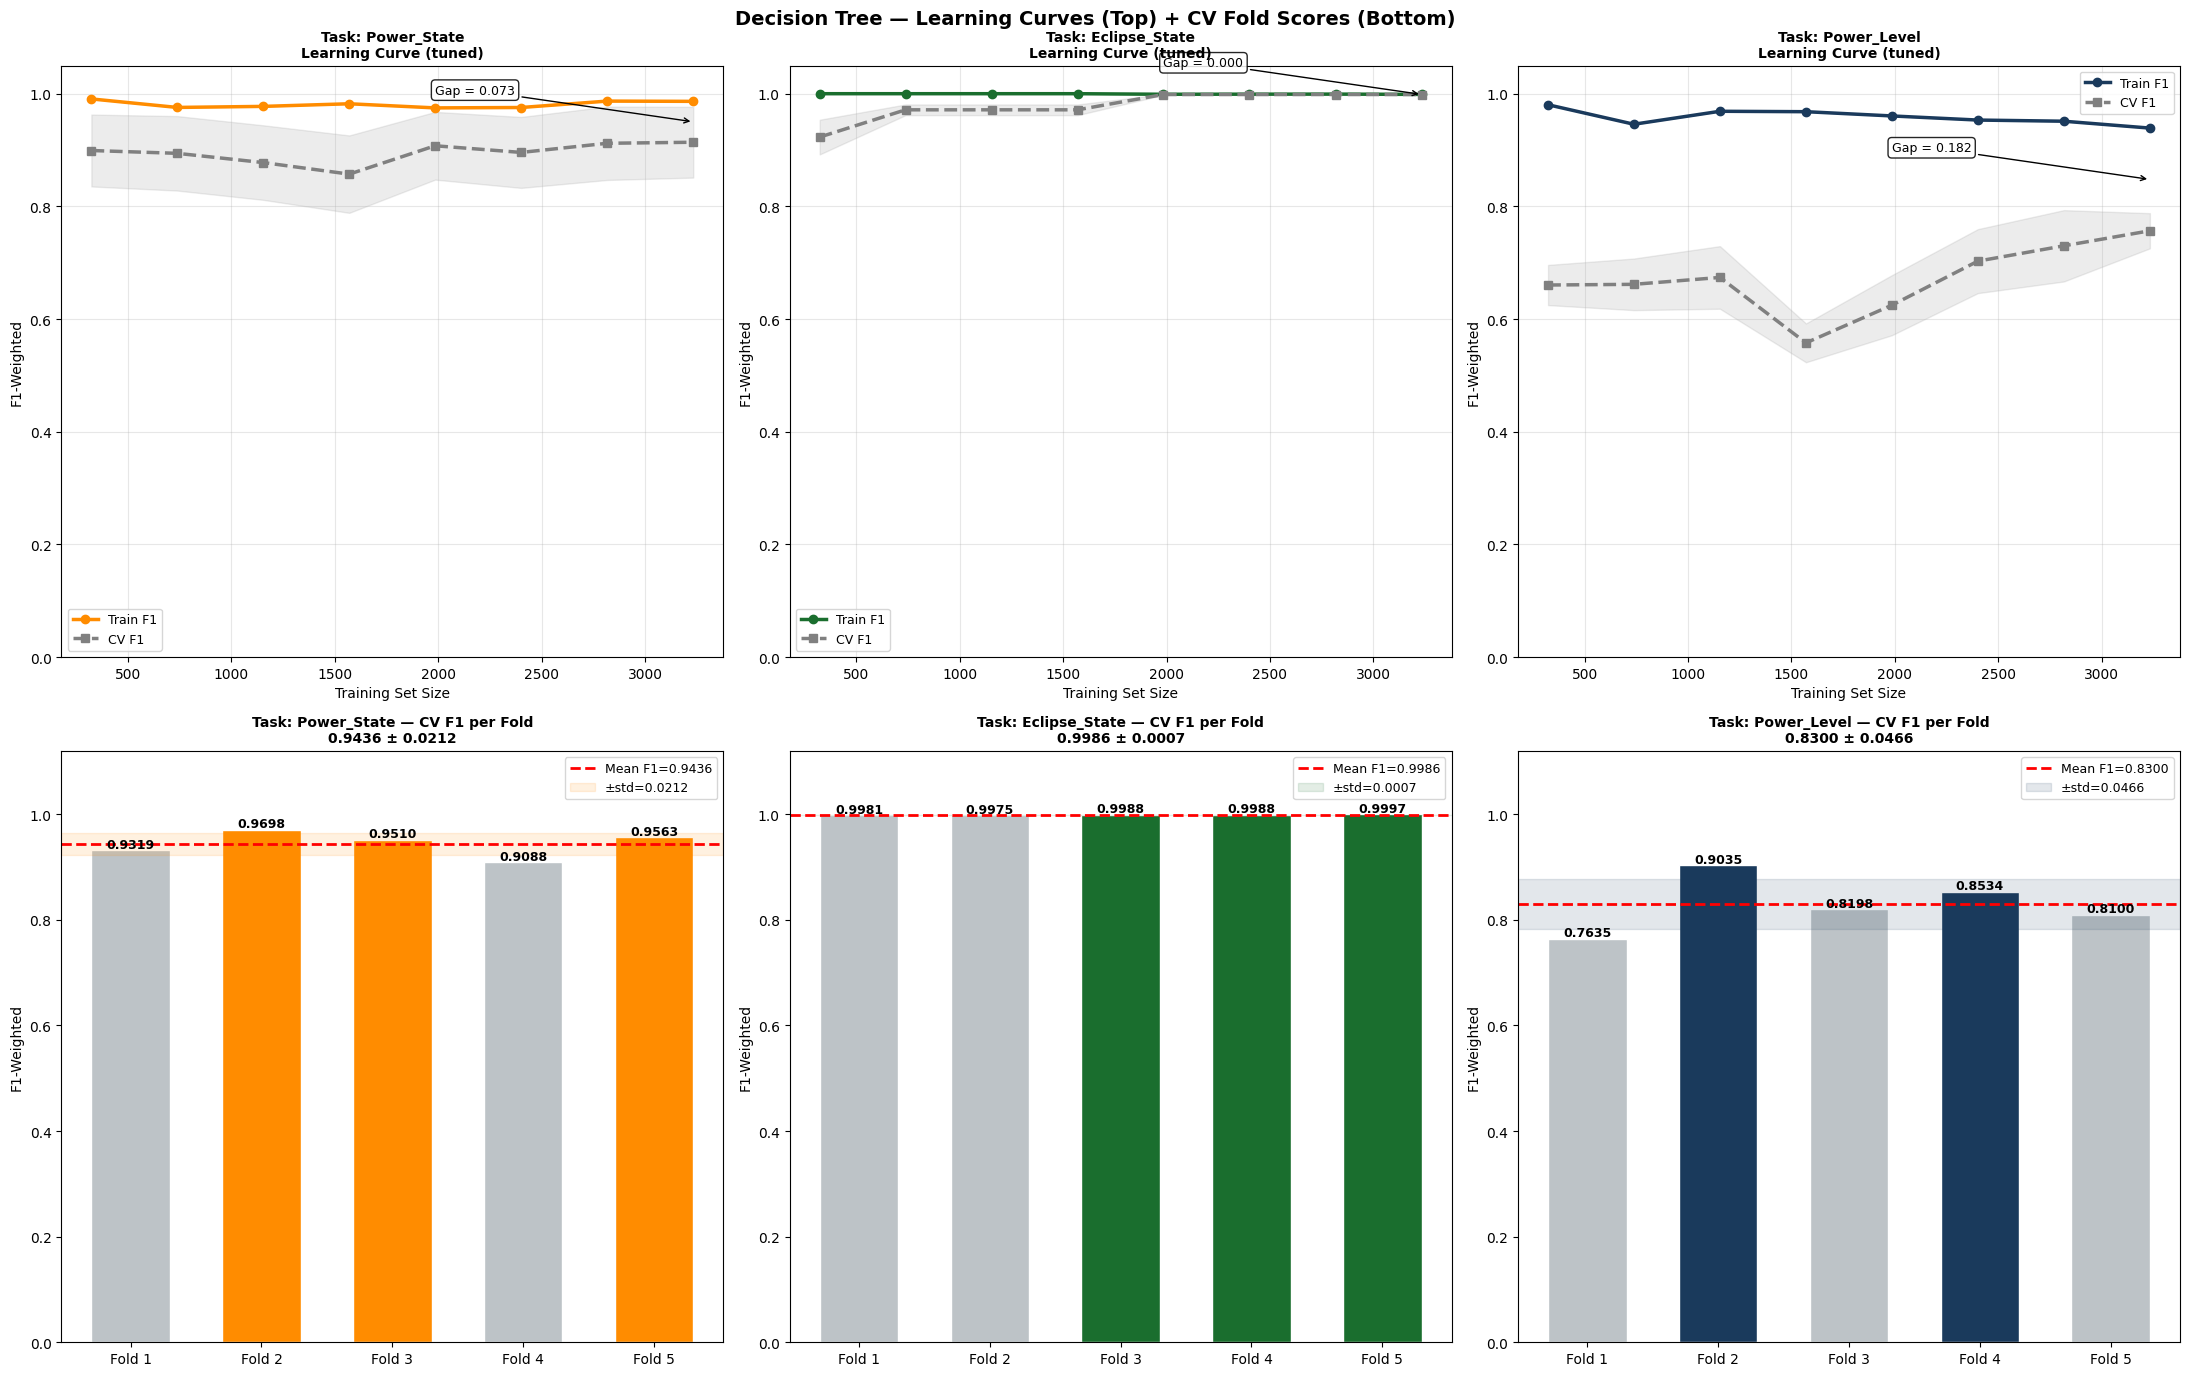


Learning curves + CV fold plots saved.


In [ ]:
# ============================================================
# SECTION 11: LEARNING CURVES + CV FOLD SCORES
# ------------------------------------------------------------
# Learning curves:
#   Unconstrained DT: train acc=1.0 at ALL training sizes
#   (perfect memorisation regardless of size).
#   Tuned DT: train and CV curves converge → good generalisation.
#   Gap = train F1 - CV F1 at max training size.
#
# CV fold scores (TimeSeriesSplit):
#   Fold 1 = smallest training window (earliest orbital data)
#   Fold 5 = largest training window
#   Declining folds → orbital pattern shift across seasons.
# ============================================================

print("Computing learning curves and CV folds...")

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle('Decision Tree — Learning Curves (Top) + CV Fold Scores (Bottom)',
             fontsize=14, fontweight='bold')

task_colors = ['darkorange', '#1a6e2e', '#1a3a5c']
cv_results  = {}

for col, (task, d, tc) in enumerate(zip(
        datasets, datasets.values(), task_colors)):
    model = results_after[task]['model']
    p     = results_after[task]['params']

    # ── Learning curves ─────────────────────────────────────
    train_sizes, train_sc, val_sc = learning_curve(
        DecisionTreeClassifier(
            max_depth         = p['max_depth'],
            min_samples_split = p['min_samples_split'],
            min_samples_leaf  = p['min_samples_leaf'],
            criterion         = p['criterion'],
            class_weight      = 'balanced',
            random_state      = SEED),
        d['X_train'], d['y_train'],
        cv           = tscv,
        train_sizes  = np.linspace(0.10, 1.0, 8),
        scoring      = 'f1_weighted',
        n_jobs       = -1)

    tr_m, tr_s = train_sc.mean(axis=1), train_sc.std(axis=1)
    va_m, va_s = val_sc.mean(axis=1),   val_sc.std(axis=1)

    ax = axes[0, col]
    ax.plot(train_sizes, tr_m, 'o-', color=tc, lw=2.5, ms=6,
            label='Train F1')
    ax.fill_between(train_sizes, tr_m-tr_s, tr_m+tr_s,
                    alpha=0.15, color=tc)
    ax.plot(train_sizes, va_m, 's--', color='gray', lw=2.5,
            ms=6, label='CV F1')
    ax.fill_between(train_sizes, va_m-va_s, va_m+va_s,
                    alpha=0.15, color='gray')

    final_gap = float(tr_m[-1] - va_m[-1])
    mid_y     = float((tr_m[-1] + va_m[-1]) / 2)
    ax.annotate(f'Gap = {final_gap:.3f}',
                xy=(train_sizes[-1], mid_y),
                xytext=(train_sizes[-4], mid_y+0.05),
                arrowprops=dict(arrowstyle='->', color='black'),
                fontsize=9,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
    ax.set_title(f'Task: {task}\nLearning Curve (tuned)',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Training Set Size'); ax.set_ylabel('F1-Weighted')
    ax.legend(fontsize=9); ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)

    # ── CV fold scores ──────────────────────────────────────
    fold_sc = cross_val_score(
        model, d['X_train'], d['y_train'],
        cv=tscv, scoring='f1_weighted', n_jobs=-1)
    cv_results[task] = fold_sc

    bar_cols = [tc if s >= fold_sc.mean() else '#bdc3c7'
                for s in fold_sc]
    ax2 = axes[1, col]
    bars = ax2.bar([f'Fold {i+1}' for i in range(5)],
                   fold_sc, color=bar_cols,
                   edgecolor='white', width=0.6)
    for bar, v in zip(bars, fold_sc):
        ax2.text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.005,
                 f'{v:.4f}', ha='center',
                 fontsize=9, fontweight='bold')
    ax2.axhline(fold_sc.mean(), color='red', ls='--', lw=2,
                label=f'Mean F1={fold_sc.mean():.4f}')
    ax2.axhspan(fold_sc.mean()-fold_sc.std(),
                fold_sc.mean()+fold_sc.std(),
                alpha=0.12, color=tc,
                label=f'±std={fold_sc.std():.4f}')
    ax2.set_title(f'Task: {task} — CV F1 per Fold\n'
                  f'{fold_sc.mean():.4f} ± {fold_sc.std():.4f}',
                  fontweight='bold', fontsize=10)
    ax2.set_ylabel('F1-Weighted'); ax2.set_ylim(0, 1.12)
    ax2.legend(fontsize=9)

    print(f"\n{task}:")
    print(f"  depth={p['max_depth']} | leaf={p['min_samples_leaf']} "
          f"| split={p['min_samples_split']} | {p['criterion']}")
    print(f"  Fold scores: {[round(s,4) for s in fold_sc]}")
    print(f"  Mean ± Std : {fold_sc.mean():.4f} ± {fold_sc.std():.4f}")

plt.tight_layout()
plt.savefig('06_learning_cv.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nLearning curves + CV fold plots saved.")

## Section 11: Learning Curves + Cross-Validation

**Power State:**
- Train F1 ≈ 0.99 at all training sizes — consistent overfitting
- CV F1 ≈ 0.91 and slowly rising — more data helps slightly
- Gap = 0.073 — moderate overfitting, acceptable after tuning
- CV: 0.9436 ± 0.0212 — stable across folds

**Eclipse State:**
- Both train and CV curves flat at ≈ 1.00 from 500 samples onward
- Gap = 0.000 — zero overfitting, perfect generalisation
- Even 10% of training data (≈380 samples) is sufficient
- CV: 0.9986 ± 0.0007 — most stable task in the entire project

**Power Level:**
- Train F1 ≈ 0.93 throughout — tree memorises training patterns
- CV F1 starts at 0.65 and rises to 0.75 — still climbing at
  max training size, meaning more data would help
- Gap = 0.182 — largest overfitting gap in this project
- CV: 0.8300 ± 0.0466 — highest fold variance
  Fold 1: 0.7635 → Fold 2: 0.9035 (14% swing between folds)
  Indicates Power Level distribution shifts significantly across
  different orbital time windows — different seasons of the
  TSURU mission have different power level patterns.

FINAL DECISION TREE — COMPLETE RESULTS SUMMARY

Task                   Model                Acc     F1-W    F1-M    CV F1          Depth  Leaves 
-------------------------------------------------------------------------------------
Power_State            Unconstrained DT     0.9058  0.9027  0.6339  0.9397±0.0249     34     495
                       Tuned DT             0.9164  0.9279  0.6386  0.9436±0.0212     19     115
                       Params: {'criterion': 'gini', 'max_depth': 26, 'max_features': None, 'min_samples_leaf': 9, 'min_samples_split': 89, 'splitter': 'best'}

Eclipse_State          Unconstrained DT     0.9977  0.9977  0.9975  0.9970±0.0024      7      19
                       Tuned DT             0.9972  0.9972  0.9969  0.9986±0.0007      4       7
                       Params: {'criterion': 'entropy', 'max_depth': 29, 'max_features': None, 'min_samples_leaf': 62, 'min_samples_split': 191, 'splitter': 'best'}

Power_Level            Unconstrained DT     0.7856  0

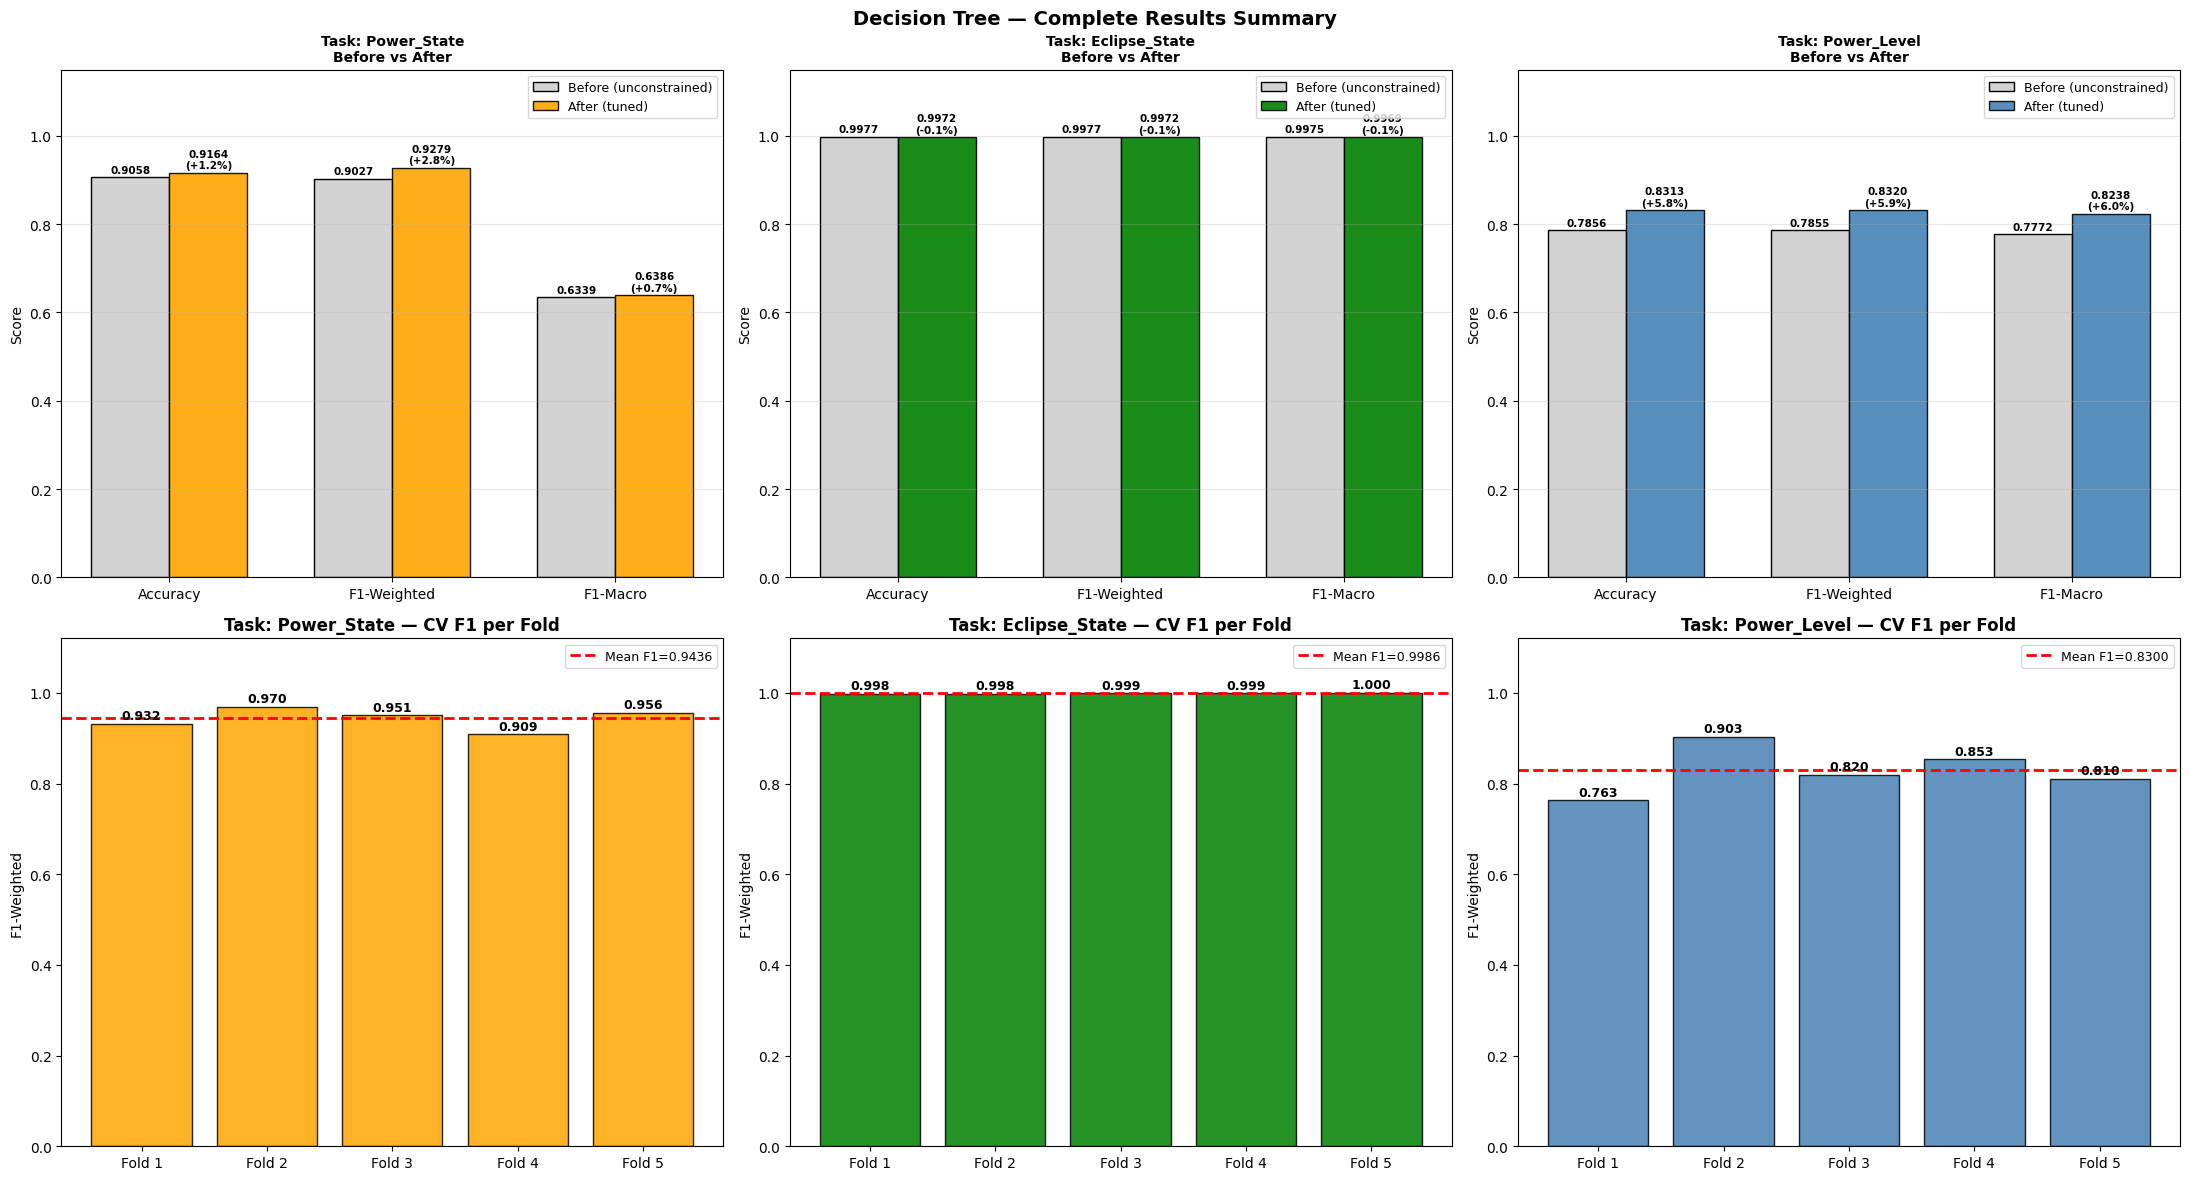

Summary plot saved.


In [ ]:
# ============================================================
# SECTION 12: COMPLETE RESULTS SUMMARY
# ============================================================

print("=" * 72)
print("FINAL DECISION TREE — COMPLETE RESULTS SUMMARY")
print("=" * 72)
print(f"\n{'Task':22} {'Model':20} {'Acc':7} {'F1-W':7} "
      f"{'F1-M':7} {'CV F1':14} {'Depth':6} {'Leaves':7}")
print("-" * 85)

for task, d in datasets.items():
    br = results_before[task]
    ar = results_after[task]
    cv = cv_results[task]
    print(f"{task:22} {'Unconstrained DT':20} "
          f"{br['acc']:.4f}  {br['f1w']:.4f}  "
          f"{br['f1m']:.4f}  "
          f"{br['cv_mean']:.4f}±{br['cv_std']:.4f}  "
          f"{br['depth']:5d}  {br['n_leaves']:6d}")
    print(f"{'':22} {'Tuned DT':20} "
          f"{ar['acc']:.4f}  {ar['f1w']:.4f}  "
          f"{ar['f1m']:.4f}  "
          f"{cv.mean():.4f}±{cv.std():.4f}  "
          f"{ar['depth']:5d}  {ar['n_leaves']:6d}")
    print(f"{'':22} Params: {ar['params']}\n")

# ── Summary visualisation ────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle('Decision Tree — Complete Results Summary',
             fontsize=14, fontweight='bold')

tc_list = ['orange', 'green', 'steelblue']

# Row 1: Before vs After
for col, (task, clr) in enumerate(zip(datasets, tc_list)):
    ax    = axes[0, col]
    b_acc = results_before[task]['acc']
    a_acc = results_after[task]['acc']
    b_f1w = results_before[task]['f1w']
    a_f1w = results_after[task]['f1w']
    b_f1m = results_before[task]['f1m']
    a_f1m = results_after[task]['f1m']
    x = np.arange(3); w = 0.35
    ax.bar(x-w/2, [b_acc,b_f1w,b_f1m], w,
           label='Before (unconstrained)',
           color='lightgray', edgecolor='black')
    ax.bar(x+w/2, [a_acc,a_f1w,a_f1m], w,
           label='After (tuned)',
           color=clr, edgecolor='black', alpha=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels(['Accuracy','F1-Weighted','F1-Macro'])
    ax.set_title(f'Task: {task}\nBefore vs After',
                 fontweight='bold', fontsize=10)
    ax.set_ylabel('Score'); ax.set_ylim([0,1.15])
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')
    for bv, av, xi in zip([b_acc,b_f1w,b_f1m],
                           [a_acc,a_f1w,a_f1m], x):
        delta = (av-bv)/max(bv,1e-9)*100
        ax.text(xi-w/2, bv+0.01, f'{bv:.4f}',
                ha='center', fontsize=7.5, fontweight='bold')
        ax.text(xi+w/2, av+0.01, f'{av:.4f}\n({delta:+.1f}%)',
                ha='center', fontsize=7.5, fontweight='bold')

# Row 2: CV fold bars
for col, (task, clr) in enumerate(zip(datasets, tc_list)):
    ax     = axes[1, col]
    scores = cv_results[task]
    bars   = ax.bar([f'Fold {i+1}' for i in range(5)],
                    scores, color=clr, edgecolor='black', alpha=0.85)
    ax.axhline(scores.mean(), color='red', ls='--', lw=2,
               label=f'Mean F1={scores.mean():.4f}')
    for bar, v in zip(bars, scores):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.01,
                f'{v:.3f}', ha='center',
                fontsize=9, fontweight='bold')
    ax.set_title(f'Task: {task} — CV F1 per Fold',
                 fontweight='bold')
    ax.set_ylabel('F1-Weighted'); ax.set_ylim([0,1.12])
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('07_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Summary plot saved.")

# DECISION TREE CLASSIFIER —  CONCLUSION
### Dataset: TSURU CubeSat On-Orbit EPS Data (Jara et al., 2022)
### DOI: 10.1016/j.dib.2022.108697

---

## ALGORITHM SUMMARY

Decision Tree learns by **recursive binary splitting** — no gradient
descent, no distance computation, no probability model.

At each node, the algorithm selects the (feature, threshold) pair
that maximises impurity reduction:

> ΔImpurity = Impurity(parent) − Σ (nᵢ/n) × Impurity(childᵢ)
> Gini = 1 − Σpᵢ²
> Entropy = −Σpᵢ log₂(pᵢ)

**No StandardScaler needed** — trees split on thresholds, feature
scale is completely irrelevant. Unlike SVM and KNN, raw sensor
values (mV, °C, mA) can be used directly.

**class_weight='balanced'** — essential for CRITICAL class (0.7%).

---

## FINAL RESULTS

| Task | Before Acc | After Acc | Before F1w | After F1w | Before F1m | After F1m |
|------|-----------|----------|-----------|----------|-----------|----------|
| Power State | 0.9058 | 0.9164 | 0.9027 | 0.9279 | 0.6339 | 0.6386 |
| Eclipse State | 0.9977 | 0.9972 | 0.9977 | 0.9972 | 0.9975 | 0.9969 |
| Power Level | 0.7856 | 0.8313 | 0.7855 | 0.8320 | 0.7772 | 0.8238 |

---

## CROSS VALIDATION (5-Fold TimeSeriesSplit)

| Task | CV F1 Mean | CV F1 Std | Fold Scores |
|------|-----------|----------|-------------|
| Power State | 0.9436 | ±0.0212 | 0.932, 0.970, 0.951, 0.909, 0.956 |
| Eclipse State | 0.9986 | ±0.0007 | 0.998, 0.998, 0.999, 0.999, 1.000 |
| Power Level | 0.8300 | ±0.0466 | 0.764, 0.904, 0.820, 0.853, 0.810 |

---

## KEY FINDINGS

### 1. Unconstrained Tree Overfits Perfectly
Train accuracy = 1.0000 on all three tasks — the defining failure
mode of Decision Trees. The tree memorises all 19,383 training
samples. Pruning via max_depth, min_samples_leaf, and
min_samples_split is mandatory, not optional.

### 2. No Feature Scaling Required
Decision Trees are completely insensitive to feature scale —
the only classifier in this project with this property.
Raw sensor values used directly.

### 3. CRITICAL Class — Tuning Made It Worse
Base model: CRITICAL F1 = 0.08
Tuned model: CRITICAL F1 = 0.04 (precision=0.03)
RandomizedSearchCV optimised f1_weighted, dominated by
CHARGING and DISCHARGING. CRITICAL was sacrificed.
Macro F1 improved only +0.7% (0.6339 → 0.6386).
This is the same fundamental limitation seen in KNN.

### 4. Eclipse State — Base Tree Already Optimal
The unconstrained base tree (depth=7, leaves=19) achieves
F1=0.9977. Tuning slightly decreased performance (-0.05%)
by over-constraining the tree to depth=4. The eclipse
boundary is captured in just 7 splits — the simplest
classification task in the project.

### 5. Power Level — Heavy Regularisation Required
Leaf sweep showed test F1 rising continuously up to leaf=45 —
the opposite of Power State. The tree overfits Power Level
more severely than any other task. Gap=0.182 is the largest
overfitting gap in this project. CV std=0.0466 indicates
the High/Medium boundary shifts across orbital seasons.

### 6. Native Gini Feature Importance
Root node feature = V_panel_avg (mV) for all three tasks.
This is the single most informative feature for all
classification decisions — physically consistent with
the panel voltage being the primary indicator of orbital
power state. Permutation importance confirms Gini ranking.

### 7. Greedy Algorithm — No Global Optimum
Decision Tree is the only classifier in this project that
does not guarantee a globally optimal solution. It finds the
locally best split at each node but cannot reconsider
earlier splits — making it fundamentally weaker than SVM
(convex QP) or Logistic Regression (gradient descent).

---

## COMPARISON WITH PREVIOUS CLASSIFIERS

| Property | Logistic Reg | KNN | SVM | Decision Tree |
|----------|-------------|-----|-----|---------------|
| Training | Gradient descent | None | Convex QP | Greedy splitting |
| Global optimum | Yes | N/A | Yes | **No** |
| Scaling needed | Yes | Yes | Yes | **No** |
| Imbalance | class_weight | None | class_weight | class_weight |
| Interpretability | Coefficients | None | SVs | **Full tree + Gini** |
| Overfit risk | Low | Medium | Low | **Very High** |
| Feature importance | Coefficients | Permutation | Permutation | **Native Gini** |
| CRITICAL F1 (tuned) | — | 0.00 | — | 0.04 |
| Power Level F1w | — | 0.8391 | — | 0.8320 |
| Eclipse F1w | — | 0.9961 | — | 0.9972 |

---

## LIMITATIONS

| Limitation | Impact |
|------------|--------|
| High variance | Small data changes → completely different tree structure |
| Greedy splits | Not globally optimal — Random Forest addresses this |
| Axis-aligned boundaries | Cannot capture diagonal class boundaries |
| CRITICAL class | Tuning sacrifices minority class for weighted F1 |
| Power Level instability | CV std=0.0466, 14% swing between folds |

---


All three problems identified in Decision Tree are addressed
by Random Forest:
- **Variance** → averaging 100+ trees reduces instability
- **Greedy splits** → ensemble of diverse trees approximates
  global optimum better than any single tree
- **Power Level overlap** → bootstrap sampling + feature
  randomness creates diverse boundaries that together
  resolve Medium/High confusion better than one tree

---

### Reference
Jara et al. (2022), *Data in Brief*
DOI: 10.1016/j.dib.2022.108697